In [1]:
from freeflux import Model, Metabolite, Reaction
from mfa import replace_uptake_reaction, make_bounds, sample_fluxes, shuffle_labeling_pattern, get_mdv_dict, carb_exch, get_mdv_results_from_simulations, calc_net_fluxes, build_flux_ratios, calc_ratios_from_sims, plot_flux_ratios, sample_ratio_specific_fluxsets, get_flux_ratio, get_flux_ratio_wide, eval_RF_sim_pred, get_reconex_fluxes, get_mdv_results, train_rf
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib
from scipy.io import loadmat
import numpy as np
from pathlib import Path
import warnings
import multiprocessing as mp
# load read sumoflux data


def melt_flux_df(data, **kwargs):
    return (
        data
        .reset_index(names="reaction_id")
        .melt(id_vars="reaction_id", var_name="sim_name", value_name="flux")
        .assign(**kwargs)
    )

def expand_metabolite_name(name):
    """
    Expand a metabolite name like 'OAA14' into
    ['OAA14_m0', 'OAA14_m1', ..., 'OAA14_mN']
    where N = (d2 - d1) + 1
    """
    match = re.match(r"(.+?)(\d)(\d)$", name)
    if not match:
        raise ValueError(f"Unexpected metabolite format: {name}")

    base, d1, d2 = match.groups()
    d1, d2 = int(d1), int(d2)

    n = (d2 - d1) + 2
    return [f"{name}_m{i}" for i in range(n)]


def matmdvs_to_pd(path_to_mat):
    
    mat = loadmat(path_to_mat)
    
    colnames = [
        x[0] for x in mat["experimentalStrains"].ravel()
    ]

    rownames = [
        x[0] for x in mat["metabolites_measured"].ravel()
    ]
    
    expanded_rownames = []
    for r in rownames:
        expanded_rownames.extend(expand_metabolite_name(r))

    # rename OGA (oxoglutaric acid) to AKG (alpha-ketoglutarate) --> more canonical
    
    expanded_rownames = [re.sub("OGA", "AKG", x) for x in expanded_rownames]
    expanded_rownames = [re.sub("PYR", "Pyr", x) for x in expanded_rownames]

    data = pd.DataFrame(
        mat["experimentalData"], index = expanded_rownames, columns = colnames
    )    
    
    return(data)


def get_reconex_fluxes_test(fluxes, multiplier, seed=42):
    rxs = fluxes.index

    reversible_mask = rxs.str.endswith(("_f", "_b"))
    reversible_rxs = rxs[reversible_mask].str.removesuffix(("_f", "_b")).unique()
    irreversible_rxs = rxs[~reversible_mask]

    net_fluxes = pd.DataFrame.from_dict(
        {r: fluxes.loc[r + "_f"] - fluxes.loc[r + "_b"] for r in reversible_rxs},
        orient="index",
    )

    rng = np.random.default_rng(seed)
    new_xchg = net_fluxes.apply(
        lambda x: np.sign(x) * rng.uniform(0, np.abs(x*multiplier)), axis=1
    )

    return pd.concat(
        [
            (net_fluxes + new_xchg)
            .where(net_fluxes > 0, -new_xchg)
            .rename(index=lambda x: x + "_f"),
            new_xchg.where(net_fluxes > 0, -(net_fluxes + new_xchg)).rename(
                index=lambda x: x + "_b"
            ),
            fluxes.loc[irreversible_rxs],
        ]
    ).reindex(rxs)

def add_noise(data, noise_scale=0.01, seed=42):
    rng = np.random.default_rng(seed)
    new_data = (data + rng.uniform(-noise_scale, noise_scale, size=data.shape)).abs()
    return new_data / new_data.sum(axis=0) 
    

def load_inputs(sim_dir, name, labeling_strat): 

    fluxes = pd.read_csv(sim_dir + name + "_fluxes.csv",index_col="Unnamed: 0")
    mdvs = pd.read_csv(sim_dir + name + "_mdvs_" + labeling_strat + "_w_noise.csv",index_col="Unnamed: 0")    
    return fluxes, mdvs

def train_rf_for_all_flux_ratios(sim_dir, flux_ratios, labeling_strat):

    input_args = [
        (
            fluxes, 
            mdvs,
            name, 
            *ratio, 
            0.3
        ) for name, ratio in flux_ratios.items() 
        for fluxes, mdvs in [load_inputs(sim_dir, name, labeling_strat)]
    ]

    with mp.Pool(3) as p:
        res = p.starmap(train_rf, input_args)
    
    res_dict = {name: ind_res for (_, _, name, _, _, _), ind_res in zip(input_args, res)}
    
    return res_dict

def xy_line(axes, ls="--", color="black", **kwargs):
    x0, x1 = axes.get_xlim()
    y0, y1 = axes.get_ylim()
    axes.plot(*[[min(x0, y0), max(x1, y1)]] * 2, ls=ls, color=color, **kwargs)


def plot_rf_results(
    results_dict, col_wrap=2, sharex=False, sharey=False, height=5, **kwargs
):
    df_pred_sim = pd.concat(
        [
            results[2].assign(flux_ratio_name=fr_name)
            for fr_name, results in results_dict.items()
        ],
        ignore_index=True,
    )

    fg = sns.FacetGrid(
        df_pred_sim,
        col="flux_ratio_name",
        col_wrap=col_wrap,
        sharex=sharex,
        sharey=sharey,
        height=height,
        **kwargs,
    ).map_dataframe(
        sns.scatterplot,
        x="simulation",
        y="prediction",
    )
    for fr_name, ax in fg.axes_dict.items():
        scores = results_dict[fr_name][1]
        ax.text(
            0.05,
            0.93,
            f"MAE: {scores['mae']:.2f}",
            fontsize=21,
            color="black",
            transform=ax.transAxes,
        )
        ax.set_xticks([0, 0.5, 1])
        ax.set_yticks([0, 0.5, 1])
        ax.tick_params(labelsize = 20)
        ax.set_xlabel("Simulation", fontsize = 21)
        ax.set_ylabel("Prediction", fontsize = 21)
        xy_line(ax)

    fg.figure.subplots_adjust(wspace = 0.3, hspace=0.3)
        
    return fg


def predict_interval(model, X, lower=5, upper=95):
    # Collect predictions from all individual trees
    tree_preds = np.array([tree.predict(X) for tree in model.estimators_])
    # tree_preds shape: (n_estimators, n_samples)
    
    lower_bound = np.percentile(tree_preds, lower, axis=0)
    upper_bound = np.percentile(tree_preds, upper, axis=0)
    point_pred  = np.mean(tree_preds, axis=0)
    
    return point_pred, lower_bound, upper_bound

def get_rf_pred_results(rf_dict, df_exp, condition, q_lower=10, q_upper=90, replace_w_nans=True):
    pred_df = (
        pd.DataFrame([
            [
                condition, 
                ratio_name, 
                *predict_interval(ratio_res[0], df_exp.sort_values("isot_model_name").query("isot_model_name in @ratio_res[0].feature_names_in_.tolist()").mdv.to_frame().transpose().values, q_lower, q_upper), 
                *ratio_res[1].values()
            ] 
            for ratio_name, ratio_res in rf_dict.items()
        ], columns=(
            "condition", 
            "flux_ratio", 
            "pred", 
            "pred_q10", 
            "pred_q90",
            "mae", 
            "cv_mae_mean", 
            "cv_mae_sd"
        ))
        .explode(["pred", "pred_q10", "pred_q90"])
        .pipe(lambda x: x.join(x.flux_ratio.str.extract(r"(?P<nucleoside>.*)_(?P<flux_ratio_name>.*)")))
    )
    
    if replace_w_nans and df_exp.mdv.isna().any():
        pred_df = pred_df.assign(pred=np.nan, pred_q10=np.nan, pred_q90=np.nan)
    return pred_df



target_emus = {
    "G6P": [1,2,3,4,5,6],
    "Pyr": [1,2,3],
    "S7P": [1,2,3,4,5,6,7],
    "Cit": [1,2,3,4,5,6],
    "Suc": [1,2,3,4],
    "Fum": [1,2,3,4],
    "Gln": [1,2,3,4,5],
    "Arg": [1,2,3,4,5,6],
    "Thr": [1,2,3,4],
    "Met": [1,2,3,4,5],
    "Asp": [1,2,3,4],
    "Asn": [1,2,3,4],
    "Ser": [1,2,3],
    "Phe": [1,2,3,4,5,6,7,8,9],
    "Tyr": [1,2,3,4,5,6,7,8,9]
}



Glc_100_U13C = dict(
    labeled_substrate = "Glc.ex", 
    labeling_pattern = ['111111'], 
    percentage = [1], 
    purity = [0.994]    
)

Glc_50_U13C_50_113C = dict(
    labeled_substrate = "Glc.ex", 
    labeling_pattern = ['111111', '100000'], 
    percentage = [0.5,0.5], 
    purity = [0.994, 0.994]    
)

Glc_100_113C = dict(
    labeled_substrate = "Glc.ex", 
    labeling_pattern = ['100000'], 
    percentage = [1], 
    purity = [0.994]    
)

glc_cond_dict = {
    "Glc_100_U13C": Glc_100_U13C, 
    "Glc_100_113C": Glc_100_113C, 
    "Glc_50_U13C_50_113C": Glc_50_U13C_50_113C
}

flux_ratios_dict_Buni = {
    "glycolysis_PPP": (["pgi"], ["pgi", "g6pdh"]),
    "PEP_from_OAA": (["pyc"], ["pyc", "eno"]), 
    "Pyr_from_PEP": (["pk"], ["pk", "me", "oad", "pdh"]), 
    "OAA_from_PEP": (["pyc"], ["pyc", "mdh", "pc"]), 
    "AKG_from_Suc": (["kdh"], ["kdh", "icd"]), 
    "Mal_from_Fum": (["fum"], ["fum", "mdh", "me"]), 
    "OAA_from_Mal": (["mdh"], ["mdh", "pyc", "pc"]), 
    "Pyr_from_Mal": (["me"], ["me", "oad", "pk"]), 
    "Suc_from_Fum": (["sdh"], ["sdh", "suc"]), 
    "Pyr_from_AcCoA": (["pdh"],["pdh", "oad", "pk", "me"]), 
    "Mal_from_OAA": (["mdh"],["mdh", "fum", "me"]),
    
    "Pyr_from_OAA": (["oad"], ["oad", "pk", "me", "pdh"]), # species specific
    "Mal_from_Pyr": (["me"], ["me", "mdh", "fum"])
    
}


flux_ratios_dict_Ecoli = {
    
    "glycolysis_PPP": (["pgi"], ["pgi", "g6pdh"]),
    "PEP_from_OAA": (["pck"], ["pck", "eno"]), 
    "Pyr_from_PEP": (["pk"], ["pk", "me"]), 
    "OAA_from_PEP": (["pyc"], ["pyc", "mdh"]), 
    "AKG_from_Suc": (["kdh"], ["kdh", "icd"]), 
    "Mal_from_Fum": (["fum"], ["fum", "mdh"]), 
    "OAA_from_Mal": (["mdh"], ["mdh", "pyc"]), 
    "Pyr_from_Mal": (["me"], ["me", "edp2", "pk"]), 
    "Suc_from_Fum": (["sdh"], ["sdh", "suc"]), 
    "Pyr_from_AcCoA": (["pfl"],["pfl", "edp2", "pk", "me"]), 
    "Mal_from_OAA": (["mdh"],["mdh", "fum"]),
    
    "Pyr_from_ED": (["edp2"], ["edp2", "me", "pk"])
    
    
}




In [2]:
# with open("../Output/DBT005G17_evaluation_Ecoli_Buni_Pvul/Ecoli/ratio_formulas.csv", "w", newline="") as f:
#     writer = csv.DictWriter(f, fieldnames=flux_ratios_dict_Buni.keys())
#     writer.writeheader()
#     writer.writerow(flux_ratios_dict_Buni)

## Simulate fluxes for Buniformis model

In [2]:
buniformis_model_file = "../Config/Models/Buniformis/Buniformis_individualBiomass.tsv"
buniformis_model = Model("Buniformis")
buniformis_model.read_from_file(buniformis_model_file)

stoic_mat = buniformis_model.get_total_stoichiometric_matrix() 
lb, ub = make_bounds(stoic_mat, 0, 100, specific={
    "glk": [10, 10], 
    "co2in": [90,100],
    "co2out": [0,100]
})

In [4]:
# simulate fluxes if not simulated yet

p = Path("../Output/species_comparison_flux_ratio_prediction/BuniPvul/ratio_specific_simulations/")
p.mkdir(parents = True, exist_ok = True)

if not Path("../Output/species_comparison_flux_ratio_prediction/BuniPvul/Buniformis_individualBiomass_fluxes.csv").exists():

    buniformis_fluxes = sample_fluxes(stoic_mat, 100000, lb, ub, thinning = 1000, reconex = 20)
    buniformis_fluxes.to_csv("../Output/species_comparison_flux_ratio_prediction/BuniPvul/Buniformis_individualBiomass_fluxes.csv")

    sample_ratio_specific_fluxsets(
        path_to_fluxes="../Output/species_comparison_flux_ratio_prediction/BuniPvul/Buniformis_individualBiomass_fluxes.csv", 
        path_to_output_dir="../Output/species_comparison_flux_ratio_prediction/BuniPvul/ratio_specific_simulations/", 
        flux_ratios_dict=flux_ratios_dict_Buni, 
        samples_per_bin=1000
    )  

# if already simulated, read in simulated fluxes
else: 
    print("Found simulated Buni/Pvul fluxes, simulation and subsampling is skipped!")

    buniformis_fluxes = pd.read_csv("../Output/species_comparison_flux_ratio_prediction/BuniPvul/Buniformis_individualBiomass_fluxes.csv", index_col = "Unnamed: 0")
    


In [5]:
# fluxes = pd.read_csv("../Output/DBT005G17_evaluation_Ecoli_Buni_Pvul/BuniPvul/Buniformis_individualBiomass_fluxes.csv", index_col = "Unnamed: 0")

# fluxes_reconex = get_reconex_fluxes_test(fluxes, multiplier = 20)

# fluxes_reconex.to_csv("../Output/DBT005G17_evaluation_Ecoli_Buni_Pvul/BuniPvul/Buniformis_individualBiomass_fluxes_reconstrained.csv")

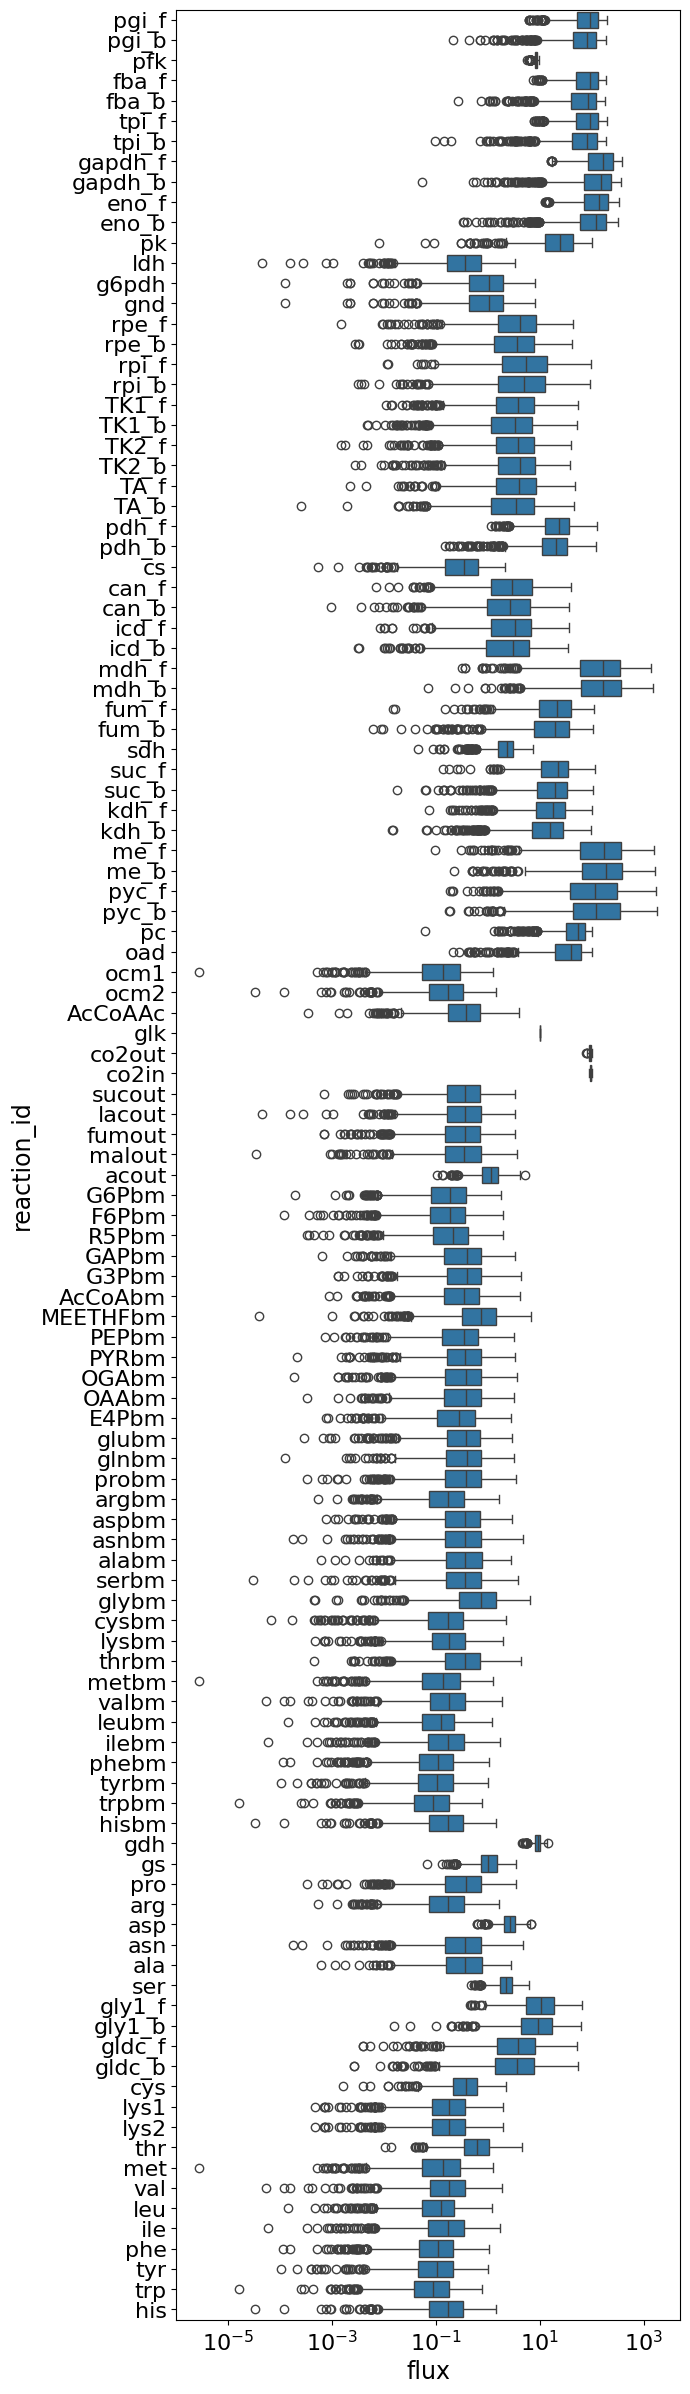

In [6]:
# double check labeling pattern distributions

# fluxes_reconex = pd.read_csv("../Output/DBT005G17_evaluation_Ecoli_Buni_Pvul/BuniPvul/Buniformis_individualBiomass_fluxes_reconstrained.csv", index_col = "Unnamed: 0")

fig, ax = plt.subplots(figsize= (6.5, 30))
ax.set_xscale('log')
plt.setp(ax.get_xticklabels(), rotation=0)
ax.tick_params(axis='both', labelsize=16)  
ax.xaxis.label.set_size(17)
ax.yaxis.label.set_size(17)
    

sns.boxplot(
    buniformis_fluxes
    .sample(n=1000, axis = 1, random_state = 87)
    .reset_index(names="reaction_id")
    .melt(id_vars="reaction_id", var_name="sim_name", value_name="flux"),
    y="reaction_id", 
    x="flux", 
    ax=ax
)

fig.savefig('../Output/species_comparison_flux_ratio_prediction/BuniPvul/flux_distribution_BuniPvul.pdf', dpi = 300, bbox_inches = "tight")


In [7]:

# Glc_100_U13C

mdvs_sub_10000 = get_mdv_results_from_simulations(buniformis_model, buniformis_fluxes.sample(n=1000, axis = 1, random_state = 87), target_emus, Glc_100_U13C, parallel=8, as_df=True)
mdvs_sub_10000_sorted = mdvs_sub_10000.sort_index()
df2 = mdvs_sub_10000_sorted.copy()
df2['subgroup'] = df2.index  # full name like Ala_123_1
df2['group'] = df2['subgroup'].str.extract(r'^([^_]+)')  # extract text before first underscore


# Melt to long fmormat (so each iteration becomes a row)
df_long2 = df2.melt(
    id_vars=['group', 'subgroup'],
    var_name='iteration',
    value_name='value'
)

df_long2['subgroup'] = df_long2["subgroup"].str.split("_").str[-1]
# make faceted boxplot

df_long2.to_csv("../Output/species_comparison_flux_ratio_prediction/BuniPvul/Buniformis_individualBiomass_mdvs_1000_U13C.csv")



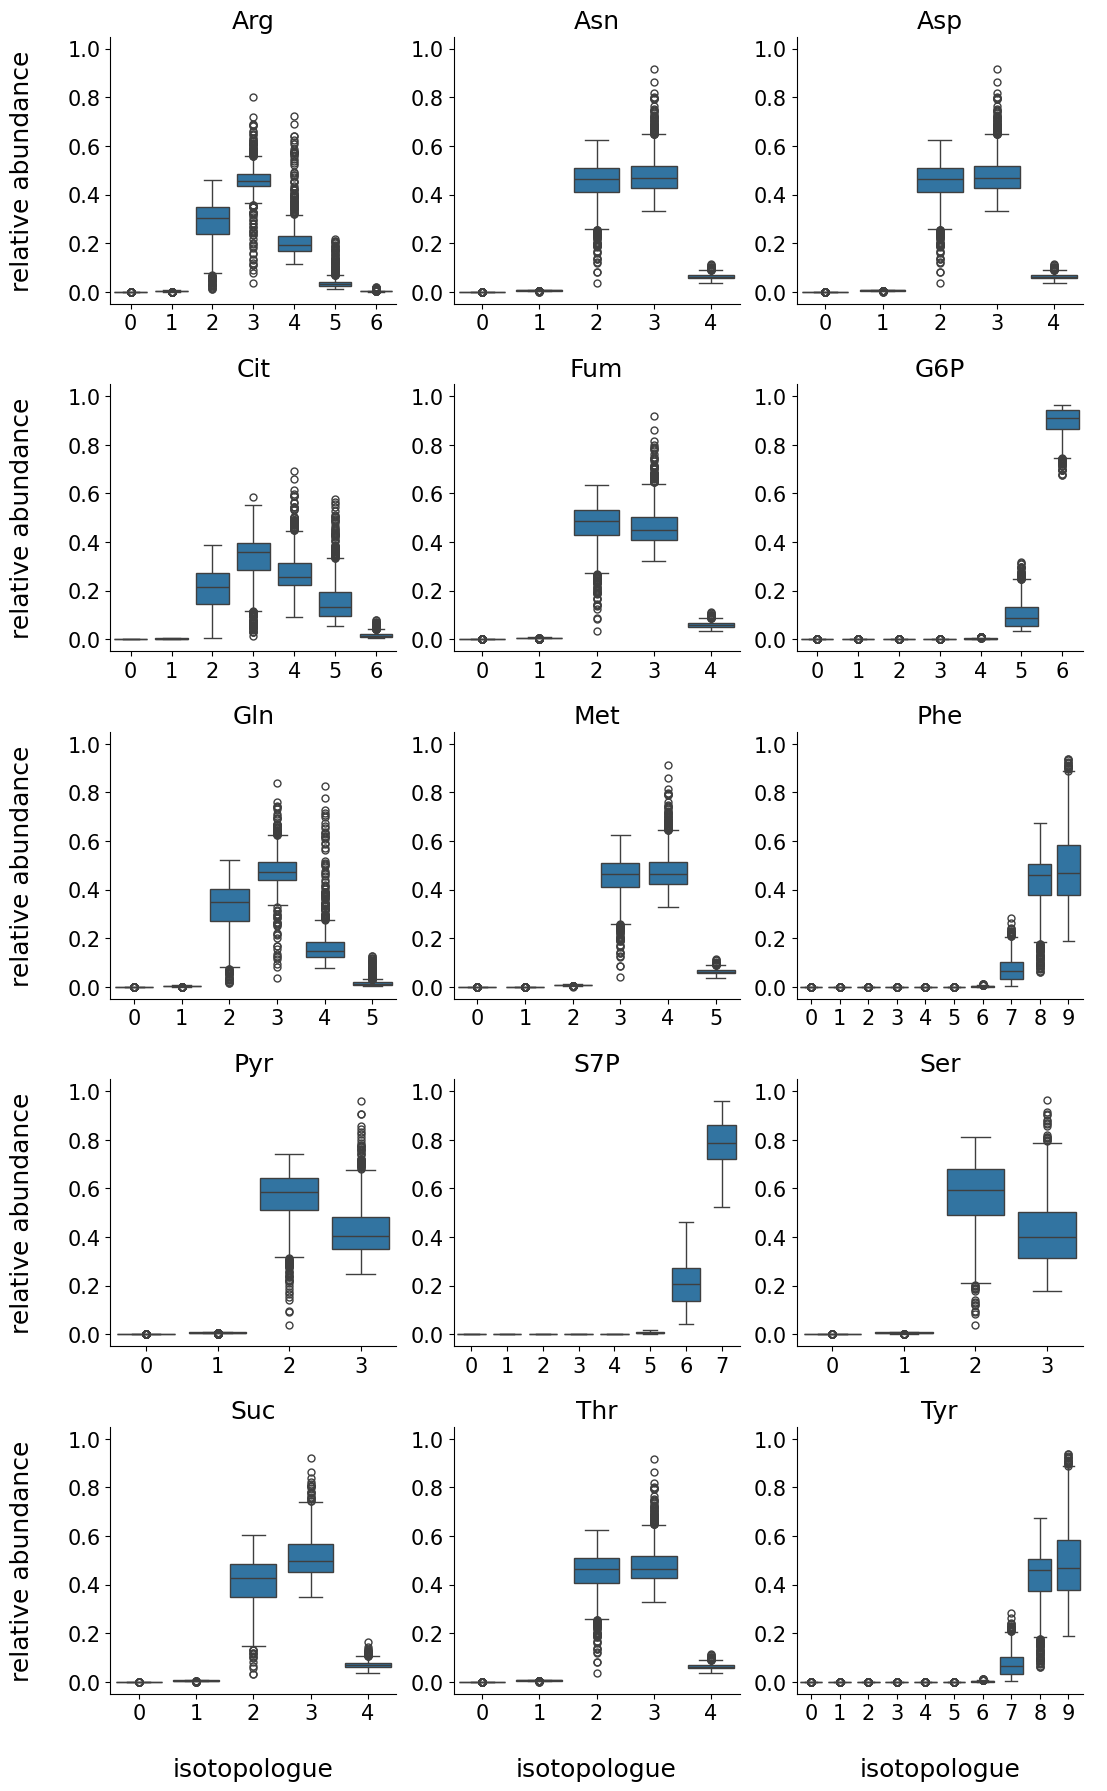

In [8]:

bxplt = sns.catplot(
    data = df_long2, 
    x = "subgroup",
    y = "value", 
    kind = "box", 
    col = "group", 
    sharex=False,
    sharey = False,
    col_wrap=3, 
    height = 3.5,
    aspect=1
    
)

bxplt.set_xticklabels(fontsize=15)
bxplt.set_axis_labels("isotopologue", "relative abundance", fontsize=18, labelpad=24)
bxplt.set_titles(template="{col_name}")
bxplt.figure.subplots_adjust(wspace=0.2, hspace=0.3)
bxplt.set(ylim=(-0.05, 1.05))

for ax in bxplt.axes.flat:
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.yaxis.set_tick_params(labelleft=True, labelsize=15)
    ax.set_title(ax.get_title(), fontsize=18)



bxplt.savefig('../Output/species_comparison_flux_ratio_prediction/BuniPvul/mdv_distribution_U13C.pdf')

# Glc_50_U13C_50_113C


In [9]:

# mdvs_sub_10000 = get_mdv_results_from_simulations(buniformis_model, fluxes.sample(n=1000, axis = 1, random_state = 87), target_emus, Glc_50_U13C_50_113C, parallel=8, as_df=True)
# mdvs_sub_10000_sorted = mdvs_sub_10000.sort_index()
# df2 = mdvs_sub_10000_sorted.copy()
# df2['subgroup'] = df2.index  # full name like Ala_123_1
# df2['group'] = df2['subgroup'].str.extract(r'^([^_]+)')  # extract text before first underscore

# # Melt to long format (so each iteration becomes a row)
# df_long2 = df2.melt(
#     id_vars=['group', 'subgroup'],
#     var_name='iteration',
#     value_name='value'
# )

# df_long2['subgroup'] = df_long2["subgroup"].str.split("_").str[-1]
# df_long2.to_csv("../Output/DBT005G17_evaluation_Ecoli_Buni_Pvul/BuniPvul/Buniformis_individualBiomass_mdvs_1000_Glc_50_U13C_50_113C.csv")
# # make faceted boxplot

# bxplt = sns.catplot(
#     data = df_long2, 
#     x = "subgroup",
#     y = "value", 
#     kind = "box", 
#     col = "group", 
#     sharex=False,
#     col_wrap=5, 
# )

# # Glc_100_113C

# mdvs_sub_10000 = get_mdv_results_from_simulations(buniformis_model, fluxes.sample(n=1000, axis = 1, random_state = 87), target_emus, Glc_100_113C, parallel=8, as_df=True)
# mdvs_sub_10000_sorted = mdvs_sub_10000.sort_index()
# df2 = mdvs_sub_10000_sorted.copy()
# df2['subgroup'] = df2.index  # full name like Ala_123_1
# df2['group'] = df2['subgroup'].str.extract(r'^([^_]+)')  # extract text before first underscore

# # Melt to long format (so each iteration becomes a row)
# df_long2 = df2.melt(
#     id_vars=['group', 'subgroup'],
#     var_name='iteration',
#     value_name='value'
# )

# df_long2['subgroup'] = df_long2["subgroup"].str.split("_").str[-1]
# df_long2.to_csv("../Output/DBT005G17_evaluation_Ecoli_Buni_Pvul/BuniPvul/Buniformis_individualBiomass_mdvs_1000_113C.csv")
# # make faceted boxplot

# bxplt = sns.catplot(
#     data = df_long2, 
#     x = "subgroup",
#     y = "value", 
#     kind = "box", 
#     col = "group", 
#     sharex=False,
#     col_wrap=5, 
# )



### Make ratio specific simulations

In [10]:
# sample_ratio_specific_fluxsets(
#     path_to_fluxes="../Output/DBT005G17_evaluation_Ecoli_Buni_Pvul/BuniPvul/Buniformis_individualBiomass_fluxes_reconstrained.csv", 
#     path_to_output_dir="../Output/DBT005G17_evaluation_Ecoli_Buni_Pvul/BuniPvul/ratio_specific_simulations/", 
#     flux_ratios_dict=flux_ratios_dict_Buni, 
#     samples_per_bin=1000
# )    

### Check Flux ratio distribution

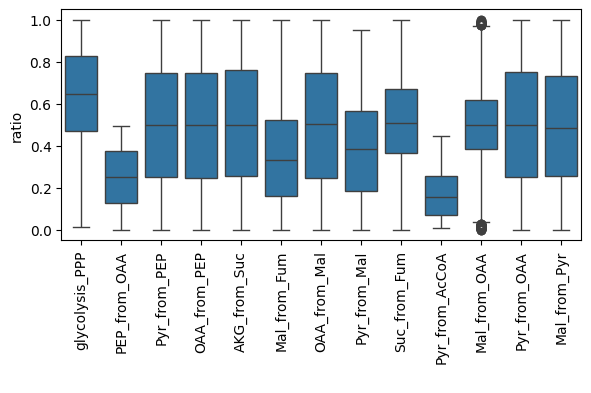

In [11]:
flux_ratios = []

all_ratios = pd.DataFrame()

for r in flux_ratios_dict_Buni.keys():
        
    fluxes = pd.read_csv("../Output/species_comparison_flux_ratio_prediction/BuniPvul/ratio_specific_simulations/" + r + "_fluxes.csv", index_col = "Unnamed: 0")
    
    flux_ratios = pd.concat([
        
        pd.concat([
            fluxes
                .pipe(get_flux_ratio, *reac_ratio)
                .assign(flux_ratio_name=name) 
            for name, reac_ratio in flux_ratios_dict_Buni.items()
        ], ignore_index=True).assign(comparison="hopsy")])
    
    flux_ratios = flux_ratios.query("flux_ratio_name == @r")
    
    all_ratios = pd.concat(
        [all_ratios, flux_ratios],
        ignore_index=True
    )


fig, ax = plt.subplots(figsize = (13, 3))
plt.setp(ax.get_xticklabels(), rotation=90)
fig.subplots_adjust(left=0.5)
ax.set(ylabel = "ratio", xlabel = " ")
sns.boxplot(
    all_ratios,
    x="flux_ratio_name",
    y="flux_ratio",
    dodge=True, 
    ax = ax
)

fig.savefig("../Output/species_comparison_flux_ratio_prediction/BuniPvul/ratio_distribution.pdf", dpi = 300, bbox_inches = "tight")

### Make MDVs for all three labeling conditions

In [12]:
for l in glc_cond_dict.keys():
    print(l)
    for r in flux_ratios_dict_Buni.keys():
        print(r)
        if not Path("../Output/species_comparison_flux_ratio_prediction/BuniPvul/ratio_specific_simulations/" + r + "_mdvs_" + l + ".csv").exists():
            print("File does not exist, simulating mdvs")
            # read in subsampled fluxes
            fluxes_subsampled = pd.read_csv("../Output/species_comparison_flux_ratio_prediction/BuniPvul/ratio_specific_simulations/" + r + "_fluxes.csv", index_col = "Unnamed: 0")
            mdvs_subsampled = get_mdv_results_from_simulations(buniformis_model, fluxes_subsampled, target_emus, glc_cond_dict[l], parallel=8, as_df=True)
            mdvs_subsampled.columns = fluxes_subsampled.columns
            mdvs_subsampled.sort_index().to_csv("../Output/species_comparison_flux_ratio_prediction/BuniPvul/ratio_specific_simulations/" + r + "_mdvs_" + l + ".csv")
        else: 
            print("simulations already conducted, going to next ratio")

Glc_100_U13C
glycolysis_PPP
File does not exist, simulating mdvs


PEP_from_OAA
File does not exist, simulating mdvs


Pyr_from_PEP
File does not exist, simulating mdvs


OAA_from_PEP
File does not exist, simulating mdvs


AKG_from_Suc
File does not exist, simulating mdvs


...

Suc_from_Fum
File does not exist, simulating mdvs


Pyr_from_AcCoA
File does not exist, simulating mdvs


Mal_from_OAA
File does not exist, simulating mdvs


Pyr_from_OAA
File does not exist, simulating mdvs


Mal_from_Pyr
File does not exist, simulating mdvs


## Add noise and remove low-abundant features

In [13]:
# per file, read in subset, add noise, filter low-abundant feats and write it again

for r in flux_ratios_dict_Buni.keys():
    
    for l in glc_cond_dict.keys():
    
        mdvs = pd.read_csv("../Output/species_comparison_flux_ratio_prediction/BuniPvul/ratio_specific_simulations/" + r + "_mdvs_" + l + ".csv", index_col = "Unnamed: 0")
        
        mdvs_wnoise = (
            mdvs
            .reset_index(names="isotopo")
            .assign(mb=lambda x: x.isotopo.str.extract("(.*_.*)_.*"))
            .set_index("isotopo")
            .groupby("mb")
            .transform(add_noise)
        )
        
        mdvs_sel = (
            mdvs_wnoise[(mdvs_wnoise > 0.05).any(axis=1)]
            .reset_index(names = "Unnamed: 0")
            .set_index("Unnamed: 0")
        )
        
        mdvs_sel.to_csv("../Output/species_comparison_flux_ratio_prediction/BuniPvul/ratio_specific_simulations/" + r + "_mdvs_" + l + "_w_noise.csv")



## Train predictors for B.uniformis model

In [14]:
p = Path("../Output/species_comparison_flux_ratio_prediction/BuniPvul/predictors_w_noise/")
p.mkdir(parents = True, exist_ok = True)


In [3]:
res_dict_Buni_100_U13C = train_rf_for_all_flux_ratios(
    sim_dir = "../Output/species_comparison_flux_ratio_prediction/BuniPvul/ratio_specific_simulations/", 
    flux_ratios = flux_ratios_dict_Buni, 
    labeling_strat = "Glc_100_U13C"
)


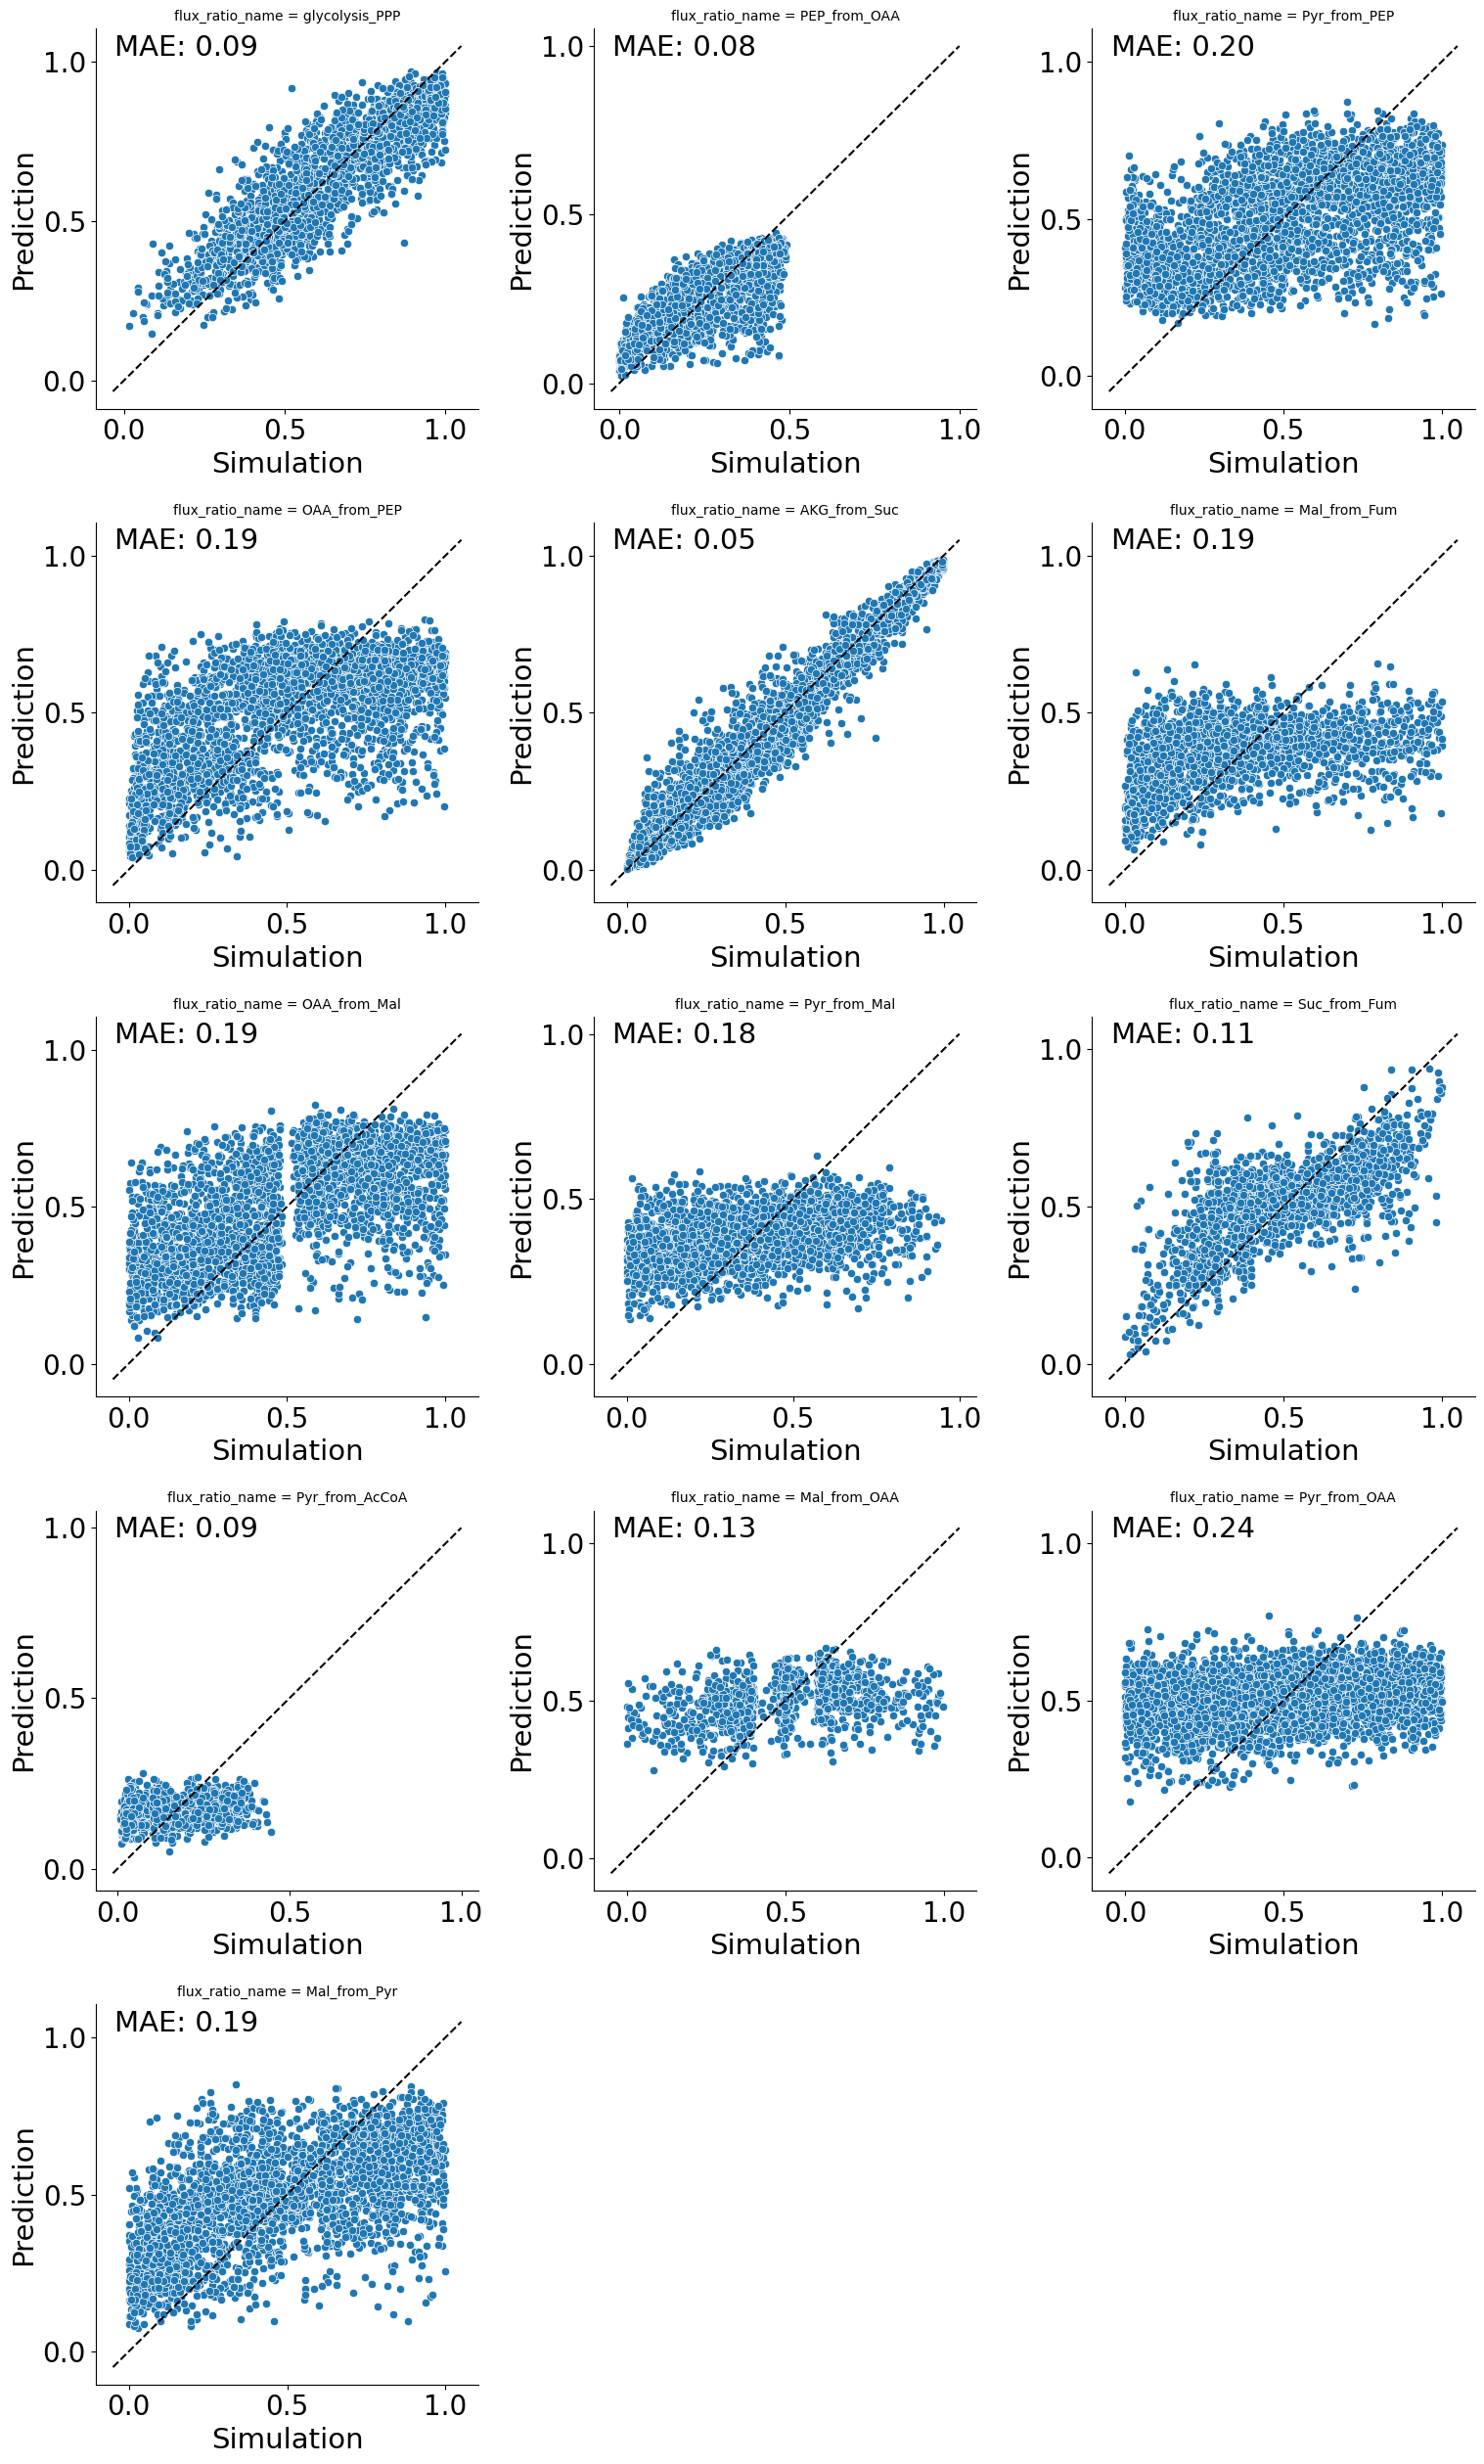

In [4]:
fg = plot_rf_results(res_dict_Buni_100_U13C, col_wrap=3)
fg.savefig("../Output/species_comparison_flux_ratio_prediction/BuniPvul/predictors_w_noise/100_U13C.pdf", dpi = 300, bbox_inches="tight")

In [5]:

res_dict_Buni_100_113C = train_rf_for_all_flux_ratios(
    sim_dir = "../Output/species_comparison_flux_ratio_prediction/BuniPvul/ratio_specific_simulations/", 
    flux_ratios = flux_ratios_dict_Buni, 
    labeling_strat = "Glc_100_113C"
)

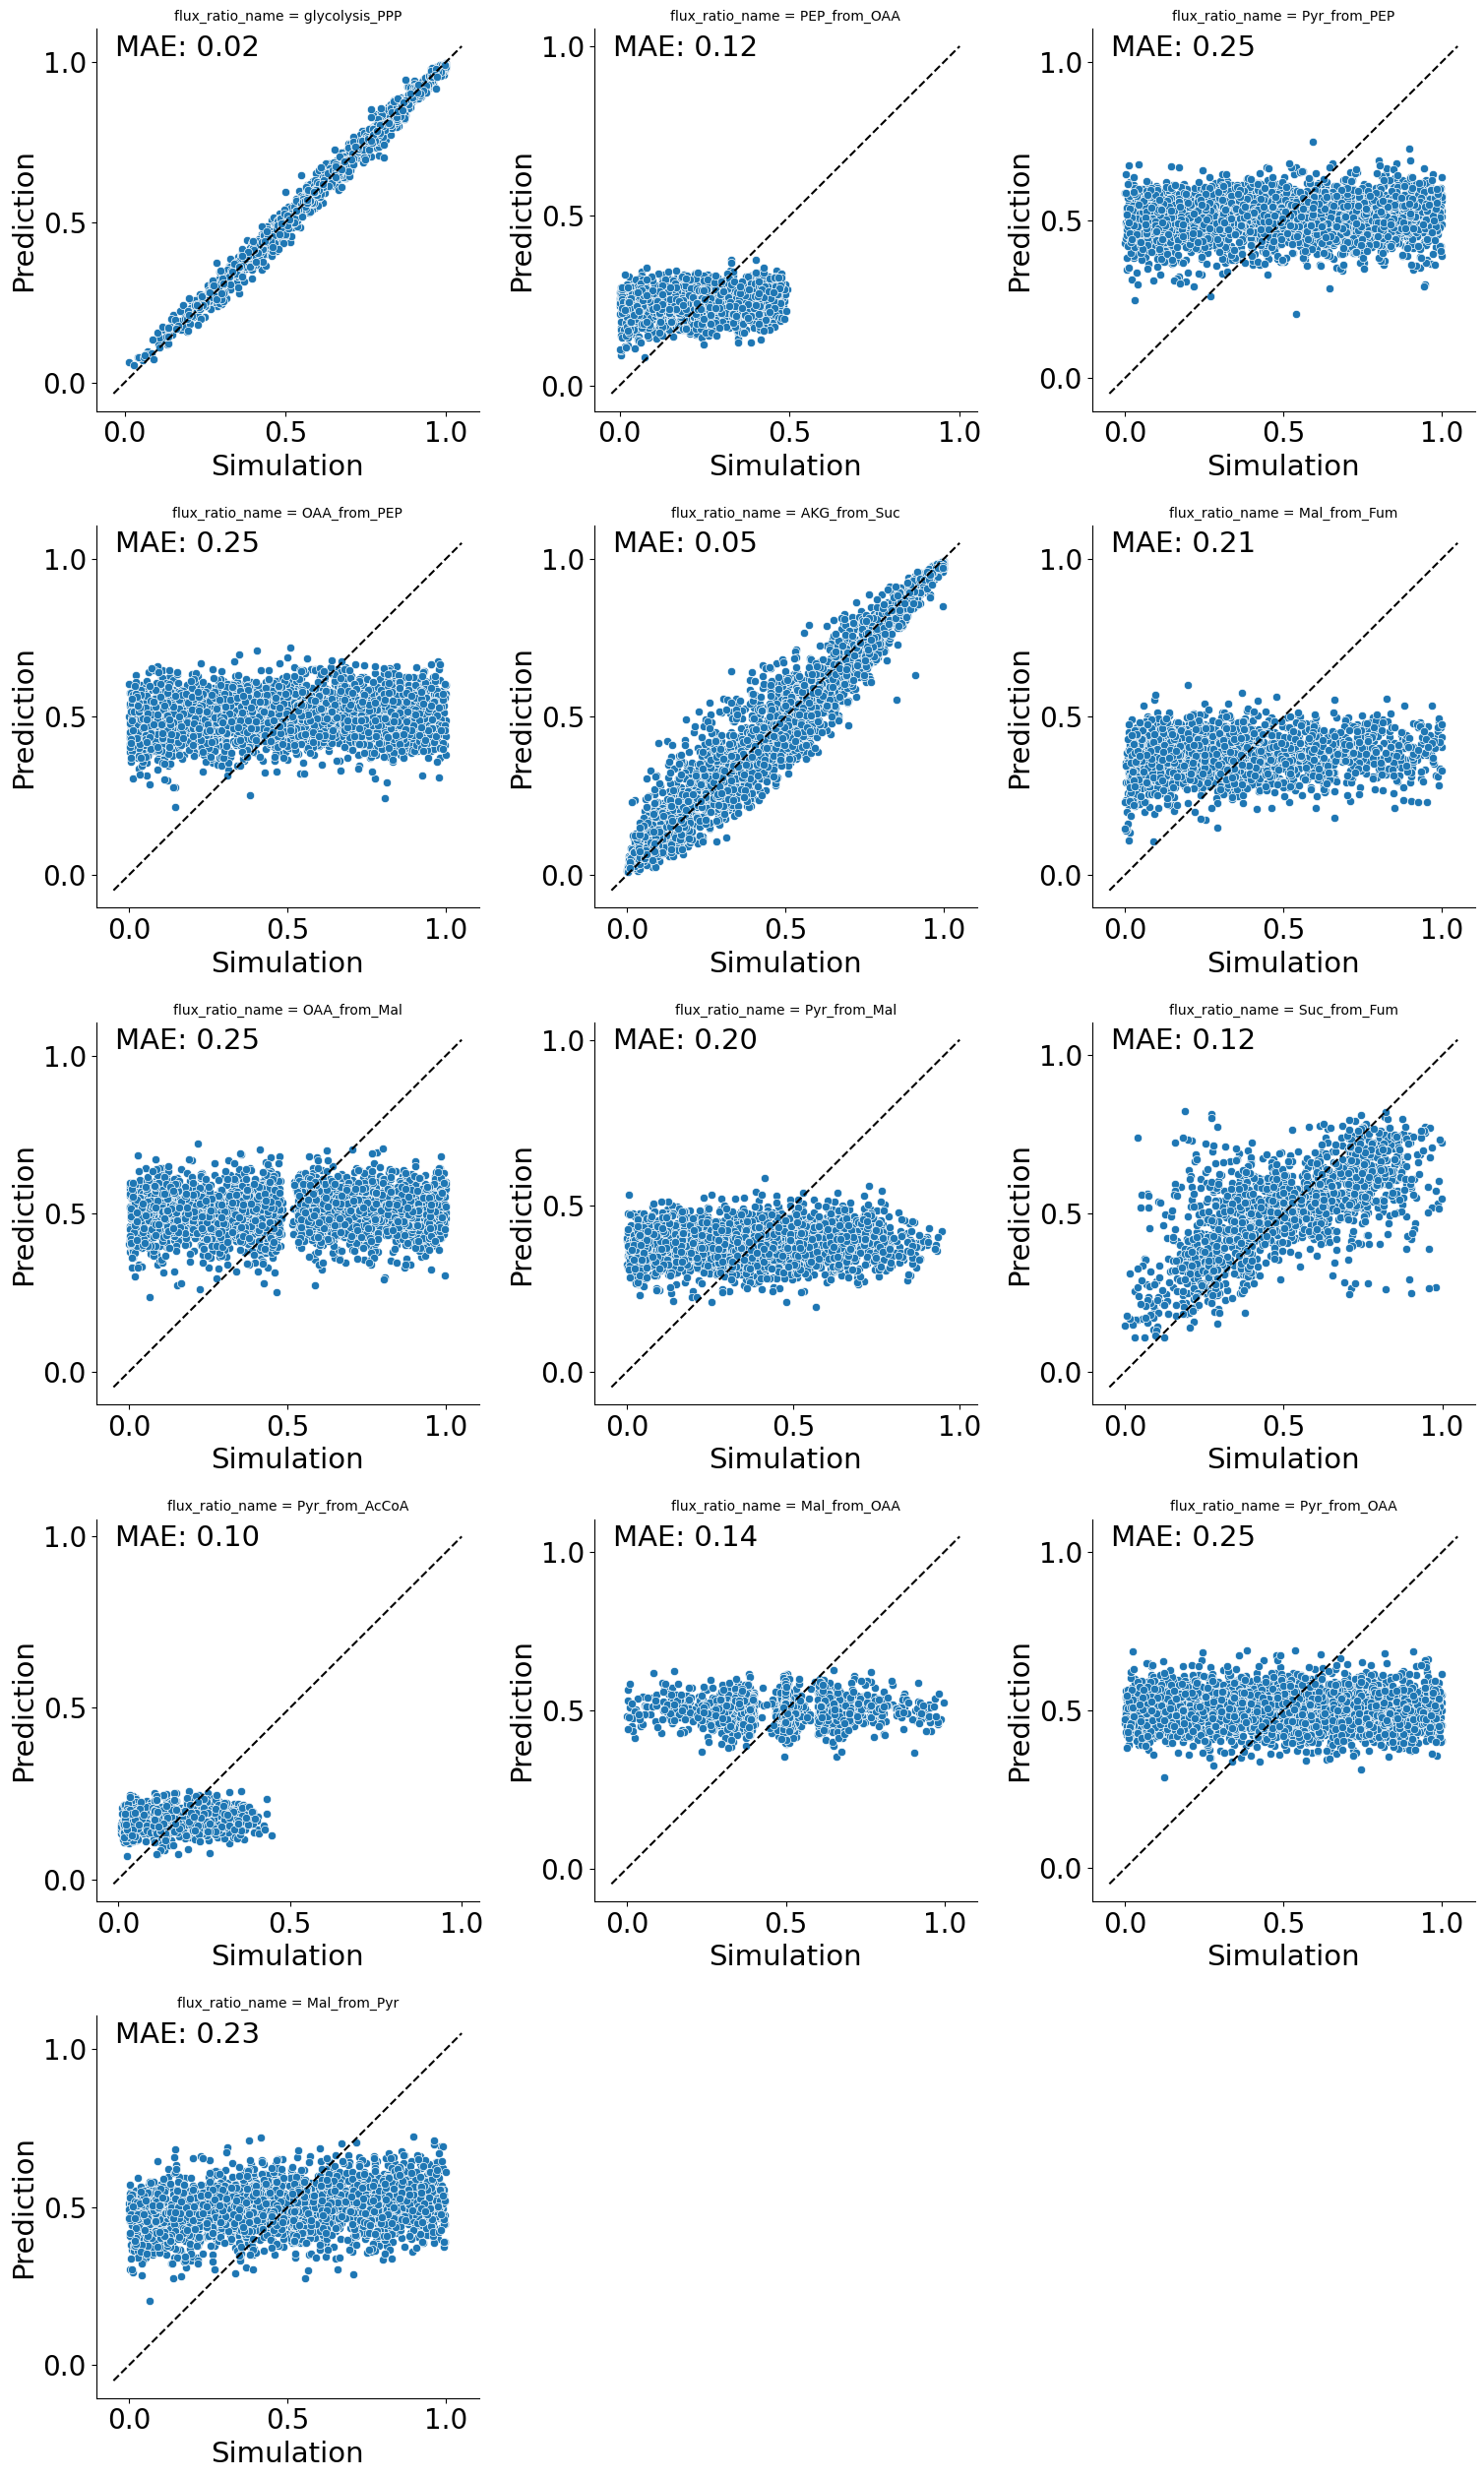

In [6]:
fg = plot_rf_results(res_dict_Buni_100_113C, col_wrap=3)
fg.savefig("../Output/species_comparison_flux_ratio_prediction/BuniPvul/predictors_w_noise/100_113C.pdf", dpi = 300, bbox_inches="tight")

In [7]:
res_dict_Buni_50_U13C_50_113C = train_rf_for_all_flux_ratios(
    sim_dir = "../Output/species_comparison_flux_ratio_prediction/BuniPvul/ratio_specific_simulations/", 
    flux_ratios = flux_ratios_dict_Buni, 
    labeling_strat = "Glc_50_U13C_50_113C"
)


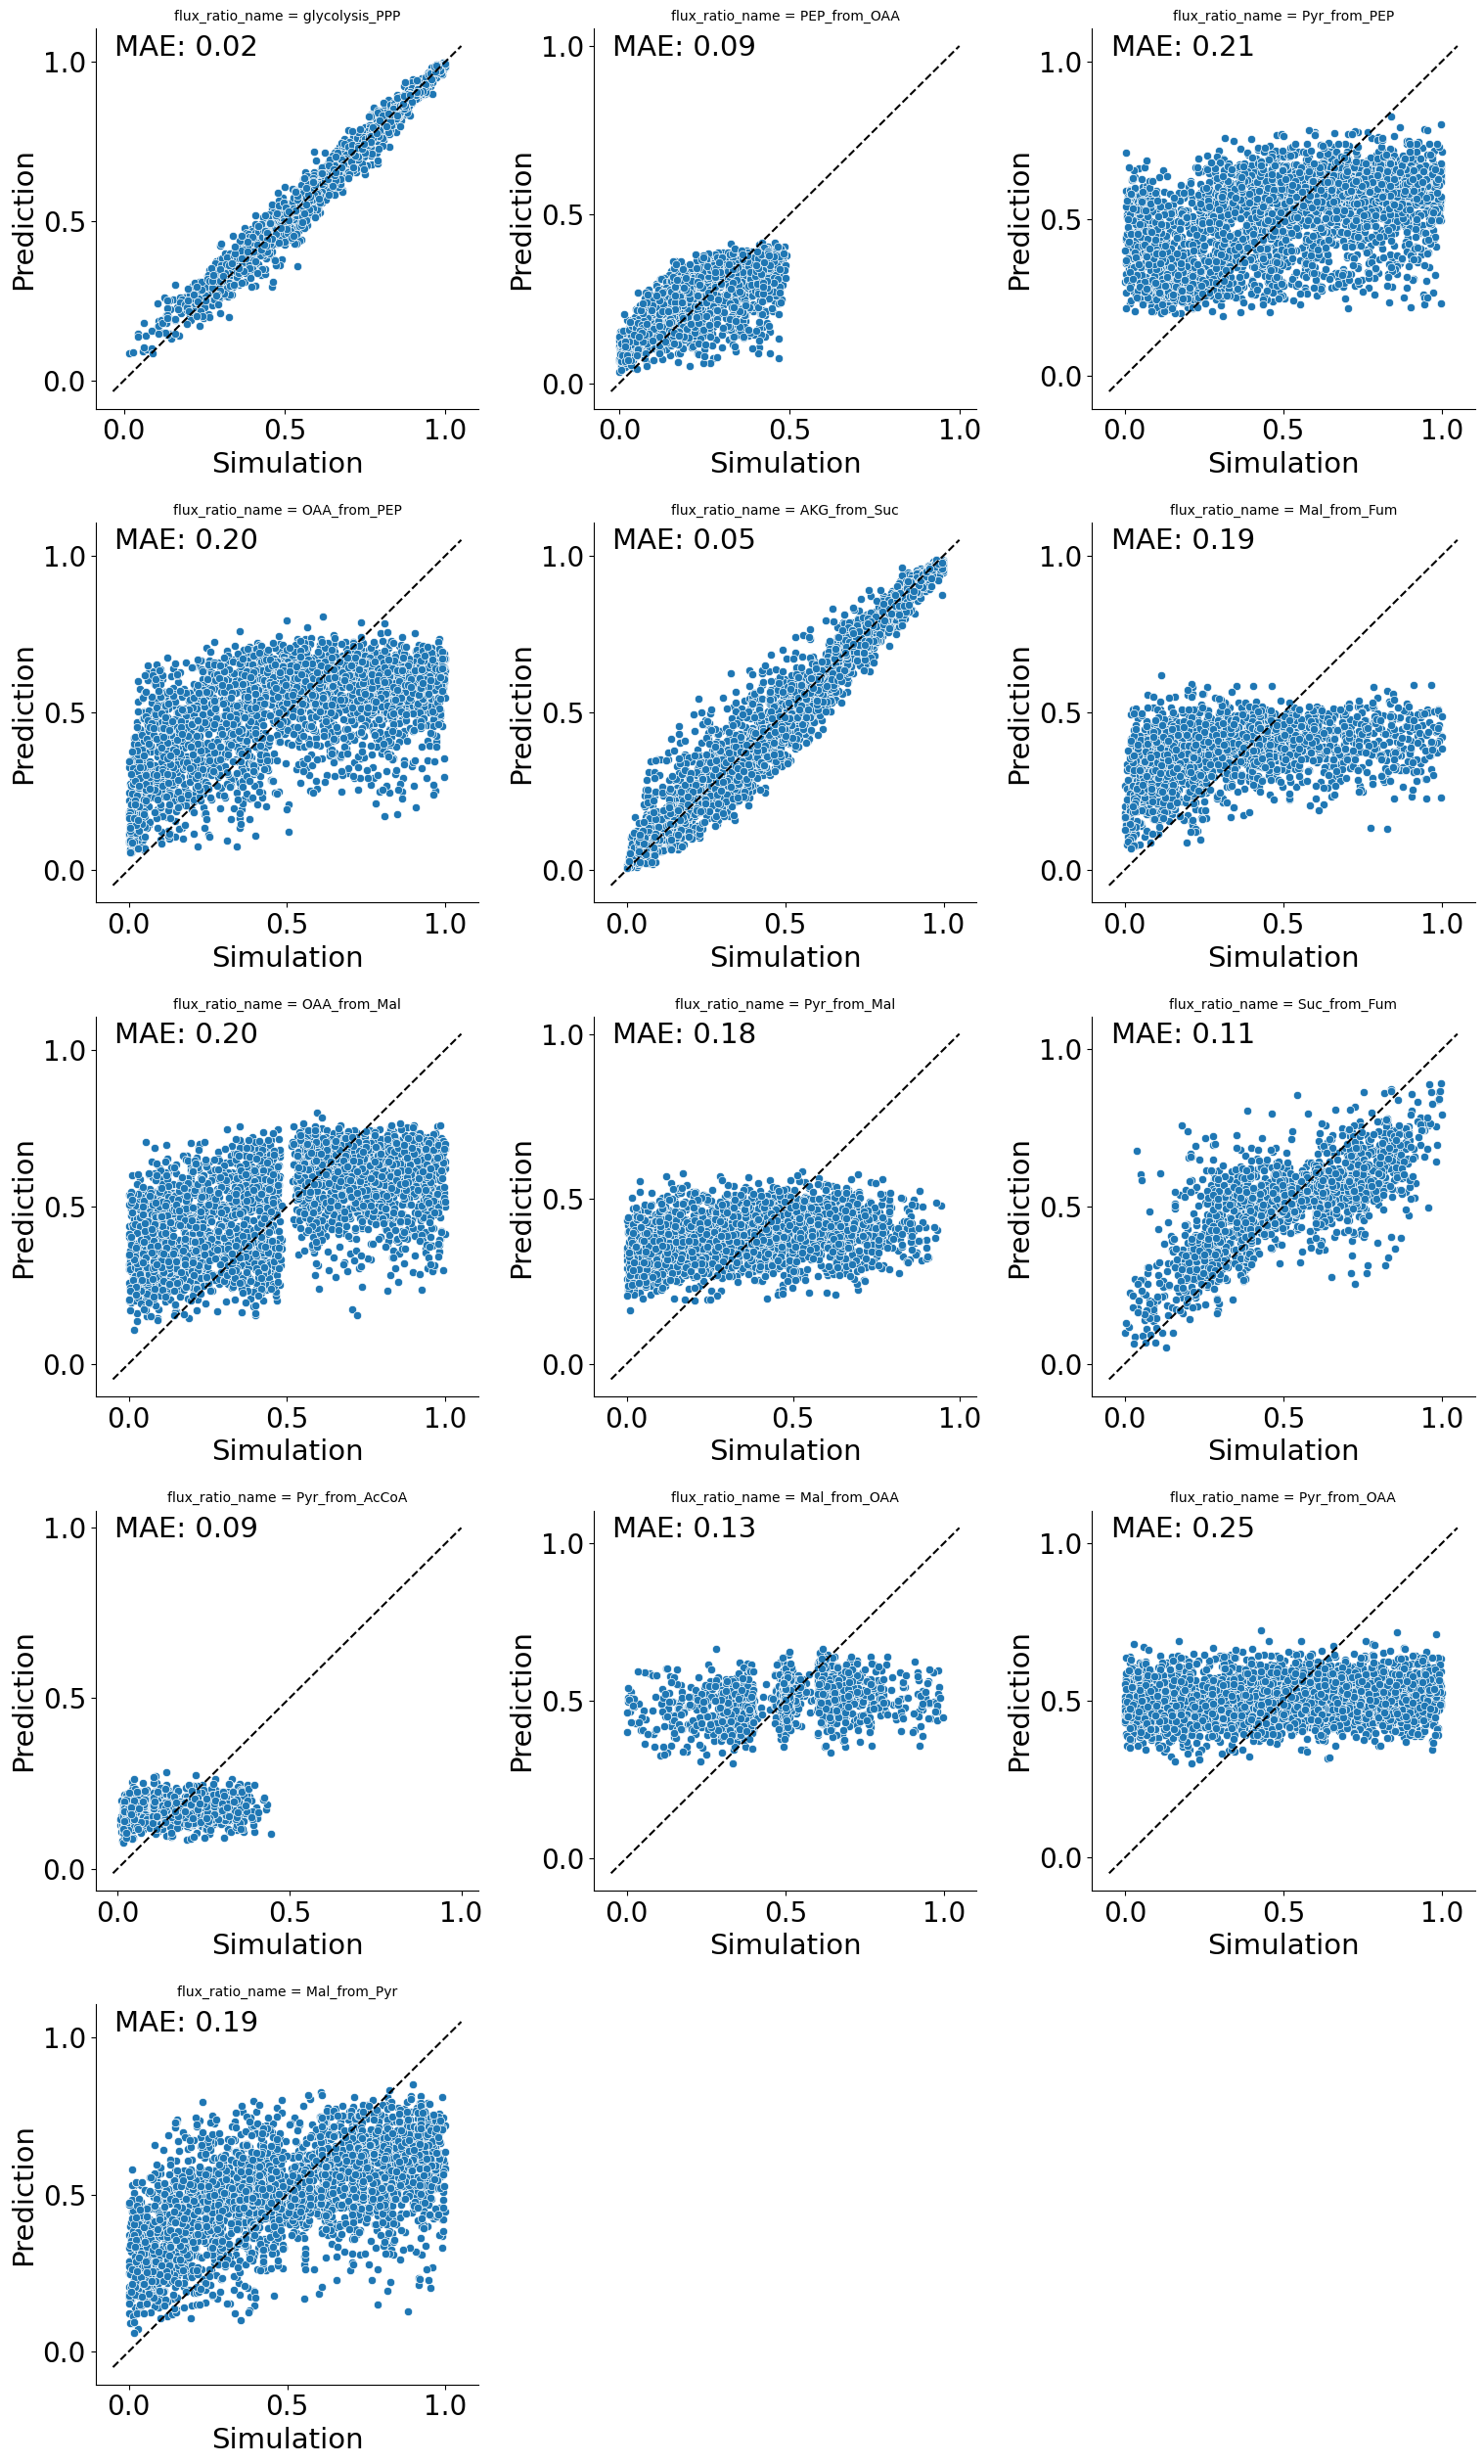

In [8]:
fg = plot_rf_results(res_dict_Buni_50_U13C_50_113C, col_wrap=3)
fg.savefig("../Output/species_comparison_flux_ratio_prediction/BuniPvul/predictors_w_noise/50_U13C_50_113C.pdf", dpi = 300, bbox_inches="tight")

In [9]:
# function to re-format species comparison output

def format_spec_comp_output(exp_df):
    output = (
        exp_df
        .reset_index()
        .pipe(lambda x: x.join(
            x.isot_model_name.str.extract(r"(?P<mb>.*)_(?P<atomnos>.*)_(?P<m>.*)", expand=True)
        ))
        .drop(columns="atomnos")
        .assign(m=lambda x: x.m.astype(int))
        .pipe(lambda x: x.merge(
            x.groupby('mb')["m"].max().apply(lambda x: "".join([str(y) for y in range(1, x+1)])).rename("atomnos").reset_index(),
            on="mb",
            how="left"
        ))
        .assign(
            isotopo=lambda x: x.mb + "_" + x.atomnos + "_" + x.m.astype(str),
            emu=lambda x:  x.mb + "_" + x.atomnos
        )
        .rename(columns={"mean": "mdv"})   
    )

    return output


In [10]:
exp_data_100_U13C = pd.read_csv("../Data/species_comparison_flux_ratio_prediction/labeling_patterns_Glc_100_U13C.csv")
exp_data_100_113C = pd.read_csv("../Data/species_comparison_flux_ratio_prediction/labeling_patterns_Glc_100_113C.csv")
exp_data_50_U13C_50_113C = pd.read_csv("../Data/species_comparison_flux_ratio_prediction/labeling_patterns_Glc_50_U13C_50_113C.csv")


preds_Buni = pd.concat([
    pd.concat([
        get_rf_pred_results(
                res_dict_Buni_100_U13C,
                format_spec_comp_output(exp_data_100_U13C).query("strain == @species"),
                "Glc_100_U13C"
            ).assign(strain = species)
            for species in exp_data_100_U13C.strain.unique().tolist()
    ]), 
    pd.concat([
        get_rf_pred_results(
                res_dict_Buni_100_113C,
                format_spec_comp_output(exp_data_100_113C).query("strain == @species"),
                "Glc_100_113C"
            ).assign(strain = species)
            for species in exp_data_100_113C.strain.unique().tolist()
    ]), 
    pd.concat([
        get_rf_pred_results(
                res_dict_Buni_50_U13C_50_113C,
                format_spec_comp_output(exp_data_50_U13C_50_113C).query("strain == @species"),
                "Glc_50_U13C_50_113C"
            ).assign(strain = species)
            for species in exp_data_50_U13C_50_113C.strain.unique().tolist()
    ])
    
])

preds_Buni.to_csv("../Output/species_comparison_flux_ratio_prediction/BuniPvul/predictions.csv")


## Perform same workflow for Ecoli

In [35]:
ecoli_model_file = "../Config/Models/Ecoli/Ecoli_individualBiomass.tsv"
ecoli_model = Model("Ecoli")
ecoli_model.read_from_file(ecoli_model_file)

stoic_mat = ecoli_model.get_total_stoichiometric_matrix() 
lb, ub = make_bounds(stoic_mat, 0, 100, specific={
    "glk": [10, 10], 
    "co2in": [90,100],
    "co2out": [0,100]
})

In [36]:
# pd.set_option("display.max_rows", None)
# print(stoic_mat.columns.tolist())

In [37]:

p = Path("../Output/species_comparison_flux_ratio_prediction/Ecoli/ratio_specific_simulations/")
p.mkdir(parents = True, exist_ok = True)

if not Path("../Output/species_comparison_flux_ratio_prediction/Ecoli/Ecoli_individualBiomass_fluxes.csv").exists():

    ecoli_fluxes = sample_fluxes(stoic_mat, 100000, lb, ub, thinning = 1000, reconex = 20)
    ecoli_fluxes.to_csv("../Output/species_comparison_flux_ratio_prediction/Ecoli/Ecoli_individualBiomass_fluxes.csv")

    sample_ratio_specific_fluxsets(
        path_to_fluxes="../Output/species_comparison_flux_ratio_prediction/Ecoli/Ecoli_individualBiomass_fluxes.csv", 
        path_to_output_dir="../Output/species_comparison_flux_ratio_prediction/Ecoli/ratio_specific_simulations/", 
        flux_ratios_dict=flux_ratios_dict_Ecoli, 
        samples_per_bin=1000
    )  

# if already simulated, read in simulated fluxes
else: 
    print("Found simulated Buni/Pvul fluxes, simulation and subsampling is skipped!")

    ecoli_fluxes = pd.read_csv("../Output/species_comparison_flux_ratio_prediction/Ecoli/Ecoli_individualBiomass_fluxes.csv", index_col = "Unnamed: 0")



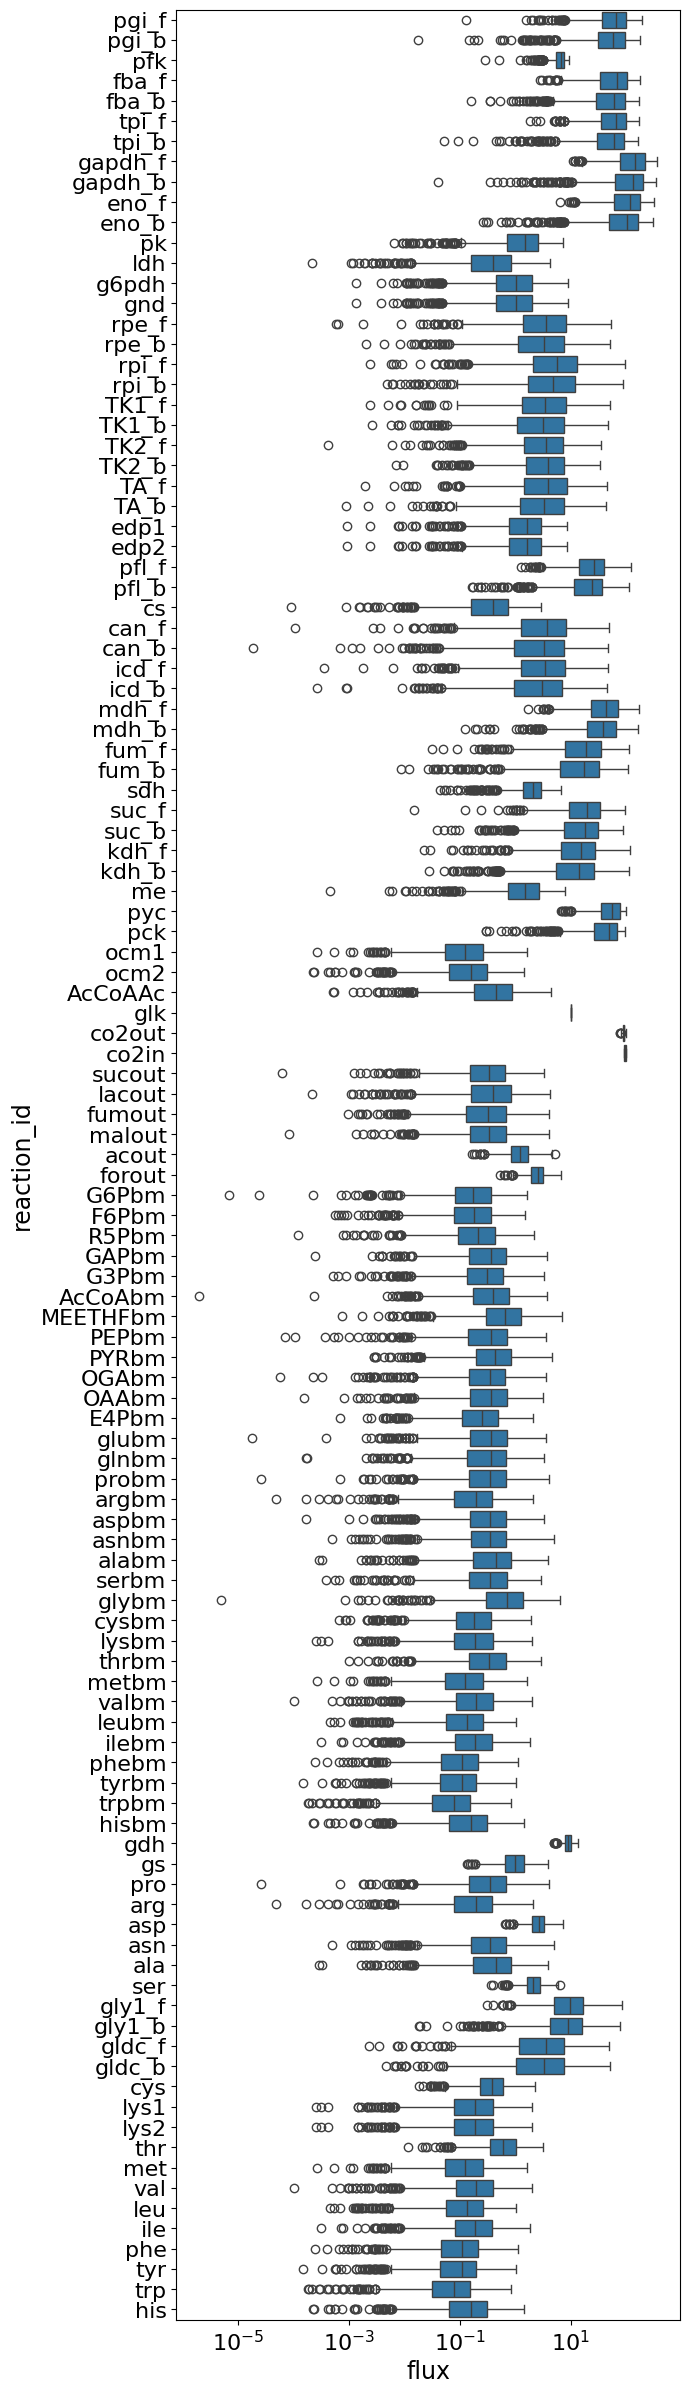

In [40]:
# double check labeling pattern distributions


fig, ax = plt.subplots(figsize= (6.5, 30))
ax.set_xscale('log')
plt.setp(ax.get_xticklabels(), rotation=0)
ax.tick_params(axis='both', labelsize=16)  
ax.xaxis.label.set_size(17)
ax.yaxis.label.set_size(17)
    

sns.boxplot(
    ecoli_fluxes
    .sample(n=1000, axis = 1, random_state = 87)
    .reset_index(names="reaction_id")
    .melt(id_vars="reaction_id", var_name="sim_name", value_name="flux"),
    y="reaction_id", 
    x="flux", 
    ax=ax
)

fig.savefig('../Output/species_comparison_flux_ratio_prediction/Ecoli/flux_distribution_Ecoli.pdf', dpi = 300, bbox_inches = "tight")


In [41]:

mdvs_sub_10000 = get_mdv_results_from_simulations(ecoli_model, ecoli_fluxes.sample(n=1000, axis = 1, random_state = 87), target_emus, Glc_100_U13C, parallel=8, as_df=True)
mdvs_sub_10000_sorted = mdvs_sub_10000.sort_index()
df2 = mdvs_sub_10000_sorted.copy()
df2['subgroup'] = df2.index  # full name like Ala_123_1
df2['group'] = df2['subgroup'].str.extract(r'^([^_]+)')  # extract text before first underscore


# Melt to long format (so each iteration becomes a row)
df_long2 = df2.melt(
    id_vars=['group', 'subgroup'],
    var_name='iteration',
    value_name='value'
)

df_long2['subgroup'] = df_long2["subgroup"].str.split("_").str[-1]
# make faceted boxplot

df_long2.to_csv("../Output/species_comparison_flux_ratio_prediction/Ecoli/Ecoli_individualBiomass_mdvs_1000_U13C.csv")



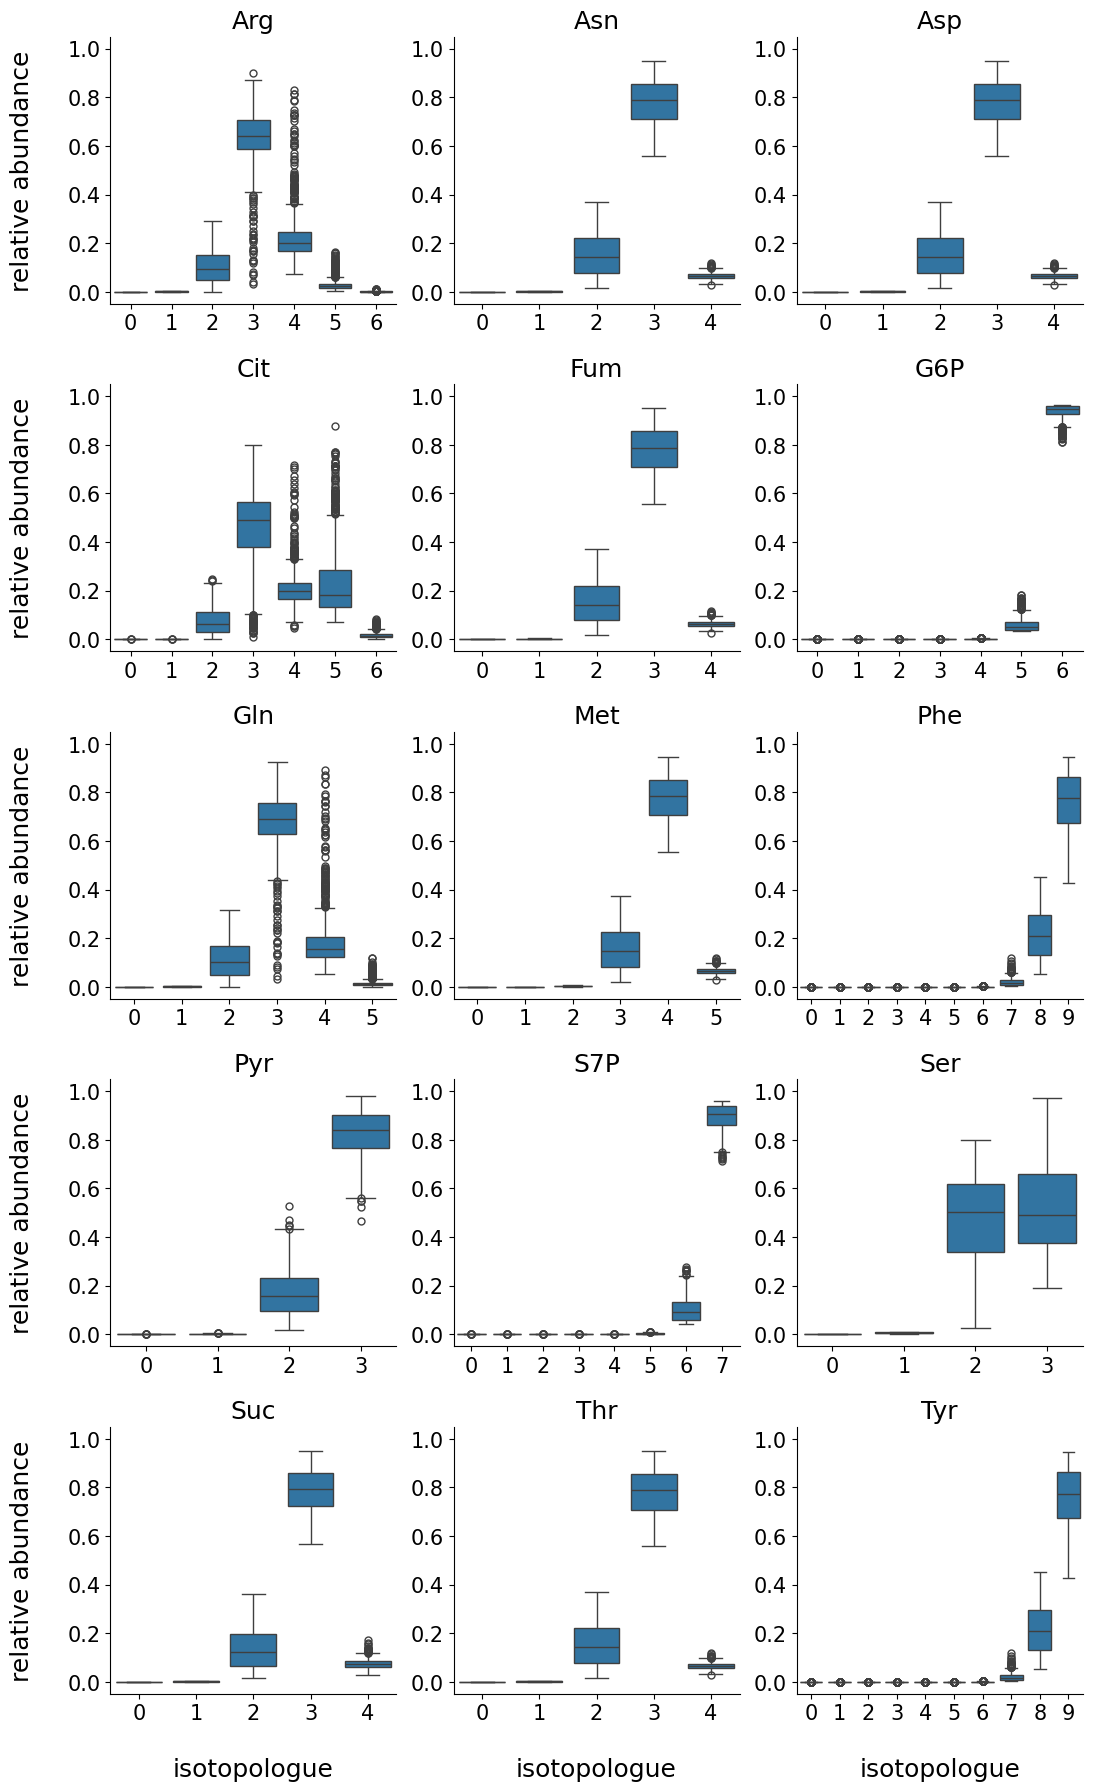

In [42]:

bxplt = sns.catplot(
    data = df_long2, 
    x = "subgroup",
    y = "value", 
    kind = "box", 
    col = "group", 
    sharex=False,
    sharey = False,
    col_wrap=3, 
    height = 3.5,
    aspect=1
    
)

bxplt.set_xticklabels(fontsize=15)
bxplt.set_axis_labels("isotopologue", "relative abundance", fontsize=18, labelpad=24)
bxplt.set_titles(template="{col_name}")
bxplt.figure.subplots_adjust(wspace=0.2, hspace=0.3)
bxplt.set(ylim=(-0.05, 1.05))

for ax in bxplt.axes.flat:
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.yaxis.set_tick_params(labelleft=True, labelsize=15)
    ax.set_title(ax.get_title(), fontsize=18)


bxplt.savefig('../Output/species_comparison_flux_ratio_prediction/Ecoli/mdv_distribution_U13C.pdf')


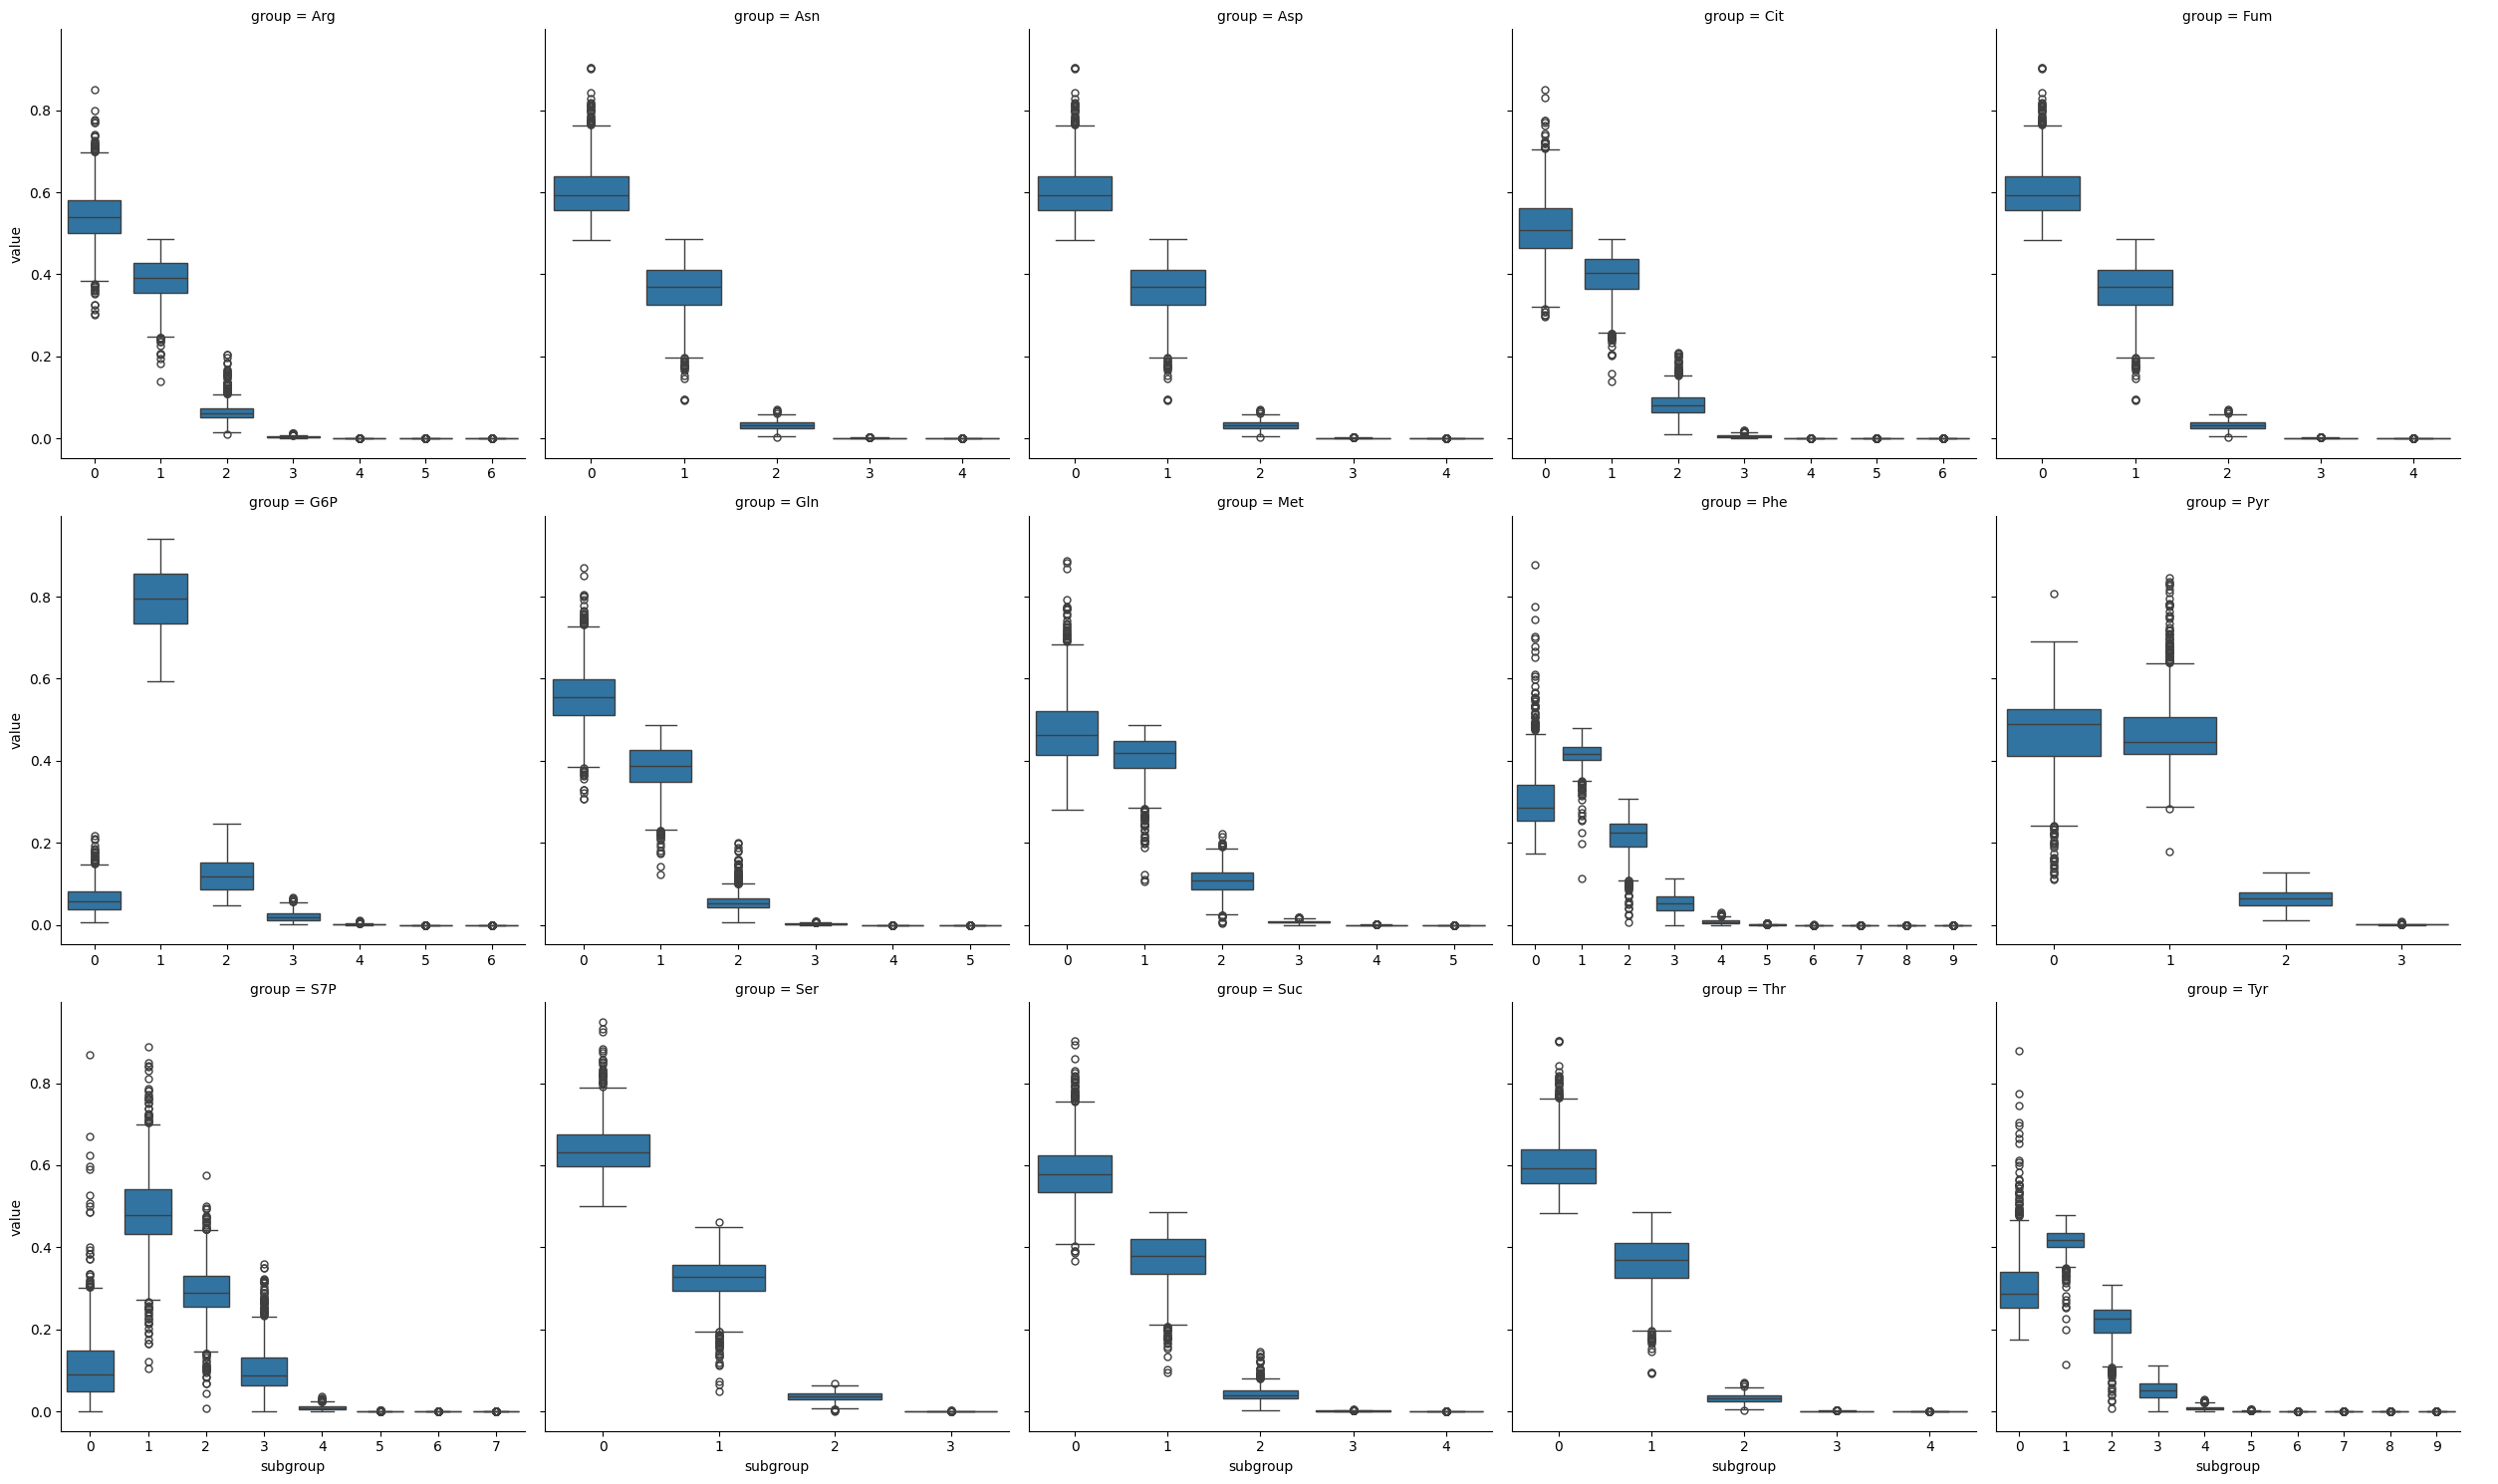

In [43]:


mdvs_sub_10000 = get_mdv_results_from_simulations(ecoli_model, ecoli_fluxes.sample(n=1000, axis = 1, random_state = 87), target_emus, Glc_100_113C, parallel=8, as_df=True)
mdvs_sub_10000_sorted = mdvs_sub_10000.sort_index()
df2 = mdvs_sub_10000_sorted.copy()
df2['subgroup'] = df2.index  # full name like Ala_123_1
df2['group'] = df2['subgroup'].str.extract(r'^([^_]+)')  # extract text before first underscore

# Melt to long format (so each iteration becomes a row)
df_long2 = df2.melt(
    id_vars=['group', 'subgroup'],
    var_name='iteration',
    value_name='value'
)

df_long2['subgroup'] = df_long2["subgroup"].str.split("_").str[-1]
df_long2.to_csv("../Output/species_comparison_flux_ratio_prediction/Ecoli/Ecoli_individualBiomass_mdvs_1000_113C.csv")
# make faceted boxplot

bxplt = sns.catplot(
    data = df_long2, 
    x = "subgroup",
    y = "value", 
    kind = "box", 
    col = "group", 
    sharex=False,
    col_wrap=5, 
)



### Check Flux ratio distribution

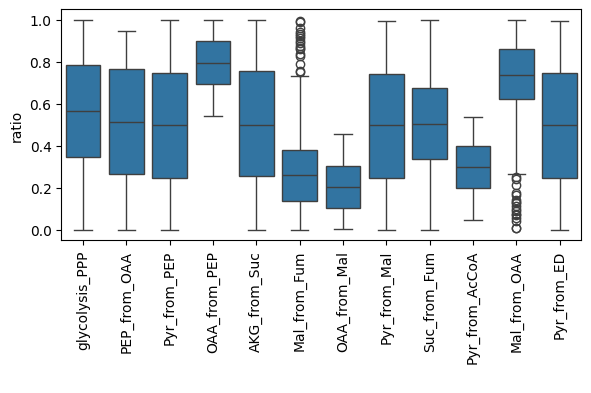

In [45]:
flux_ratios = []

all_ratios = pd.DataFrame()

for r in flux_ratios_dict_Ecoli.keys():
        
    fluxes = pd.read_csv("../Output/species_comparison_flux_ratio_prediction/Ecoli/ratio_specific_simulations/" + r + "_fluxes.csv", index_col = "Unnamed: 0")
    
    flux_ratios = pd.concat([
        
        pd.concat([
            fluxes
                .pipe(get_flux_ratio, *reac_ratio)
                .assign(flux_ratio_name=name) 
            for name, reac_ratio in flux_ratios_dict_Ecoli.items()
        ], ignore_index=True).assign(comparison="hopsy")])
    
    flux_ratios = flux_ratios.query("flux_ratio_name == @r")
    
    all_ratios = pd.concat(
        [all_ratios, flux_ratios],
        ignore_index=True
    )
 

fig, ax = plt.subplots(figsize = (13, 3))
plt.setp(ax.get_xticklabels(), rotation=90)
fig.subplots_adjust(left=0.5)
ax.set(ylabel = "ratio", xlabel = " ")
sns.boxplot(
    all_ratios,
    x="flux_ratio_name",
    y="flux_ratio",
    dodge=True, 
    ax = ax
)

fig.savefig("../Output/species_comparison_flux_ratio_prediction/Ecoli/ratio_distribution.pdf", dpi = 300, bbox_inches = "tight")

### Make MDVs for all three labeling conditions

In [46]:
for l in glc_cond_dict.keys():
    print(l)
    for r in flux_ratios_dict_Ecoli.keys():
        print(r)
        if not Path("../Output/species_comparison_flux_ratio_prediction/Ecoli/ratio_specific_simulations/" + r + "_mdvs_" + l + ".csv").exists():
            print("File does not exist, simulating mdvs")
            # read in subsampled fluxes
            fluxes_subsampled = pd.read_csv("../Output/species_comparison_flux_ratio_prediction/Ecoli/ratio_specific_simulations/" + r + "_fluxes.csv", index_col = "Unnamed: 0")
            mdvs_subsampled = get_mdv_results_from_simulations(ecoli_model, fluxes_subsampled, target_emus, glc_cond_dict[l], parallel=8, as_df=True)
            mdvs_subsampled.columns = fluxes_subsampled.columns
            mdvs_subsampled.sort_index().to_csv("../Output/species_comparison_flux_ratio_prediction/Ecoli/ratio_specific_simulations/" + r + "_mdvs_" + l + ".csv")
        else: 
            print("simulations already conducted, going to next ratio")

Glc_100_U13C
glycolysis_PPP
File does not exist, simulating mdvs


PEP_from_OAA
File does not exist, simulating mdvs


Pyr_from_PEP
File does not exist, simulating mdvs


OAA_from_PEP
File does not exist, simulating mdvs


AKG_from_Suc
File does not exist, simulating mdvs


...

Pyr_from_Mal
File does not exist, simulating mdvs


Suc_from_Fum
File does not exist, simulating mdvs


Pyr_from_AcCoA
File does not exist, simulating mdvs


Mal_from_OAA
File does not exist, simulating mdvs


Pyr_from_ED
File does not exist, simulating mdvs


## Add noise and remove low-abundant features

In [47]:
# per file, read in subset, add noise, filter low-abundant feats and write it again

for r in flux_ratios_dict_Ecoli.keys():
    
    for l in glc_cond_dict.keys():
    
        mdvs = pd.read_csv("../Output/species_comparison_flux_ratio_prediction/Ecoli/ratio_specific_simulations/" + r + "_mdvs_" + l + ".csv", index_col = "Unnamed: 0")
        
        mdvs_wnoise = (
            mdvs
            .reset_index(names="isotopo")
            .assign(mb=lambda x: x.isotopo.str.extract("(.*_.*)_.*"))
            .set_index("isotopo")
            .groupby("mb")
            .transform(add_noise)
        )
        
        mdvs_sel = (
            mdvs_wnoise[(mdvs_wnoise > 0.05).any(axis=1)]
            .reset_index(names = "Unnamed: 0")
            .set_index("Unnamed: 0")
        )
        
        mdvs_sel.to_csv("../Output/species_comparison_flux_ratio_prediction/Ecoli/ratio_specific_simulations/" + r + "_mdvs_" + l + "_w_noise.csv")



## Train predictors for B.uniformis model

In [48]:
p = Path("../Output/species_comparison_flux_ratio_prediction/Ecoli/predictors_w_noise/")
p.mkdir(parents = True, exist_ok = True)


In [49]:
res_dict_Ecoli_100_U13C = train_rf_for_all_flux_ratios(
    sim_dir = "../Output/species_comparison_flux_ratio_prediction/Ecoli/ratio_specific_simulations/", 
    flux_ratios = flux_ratios_dict_Ecoli, 
    labeling_strat = "Glc_100_U13C"
)


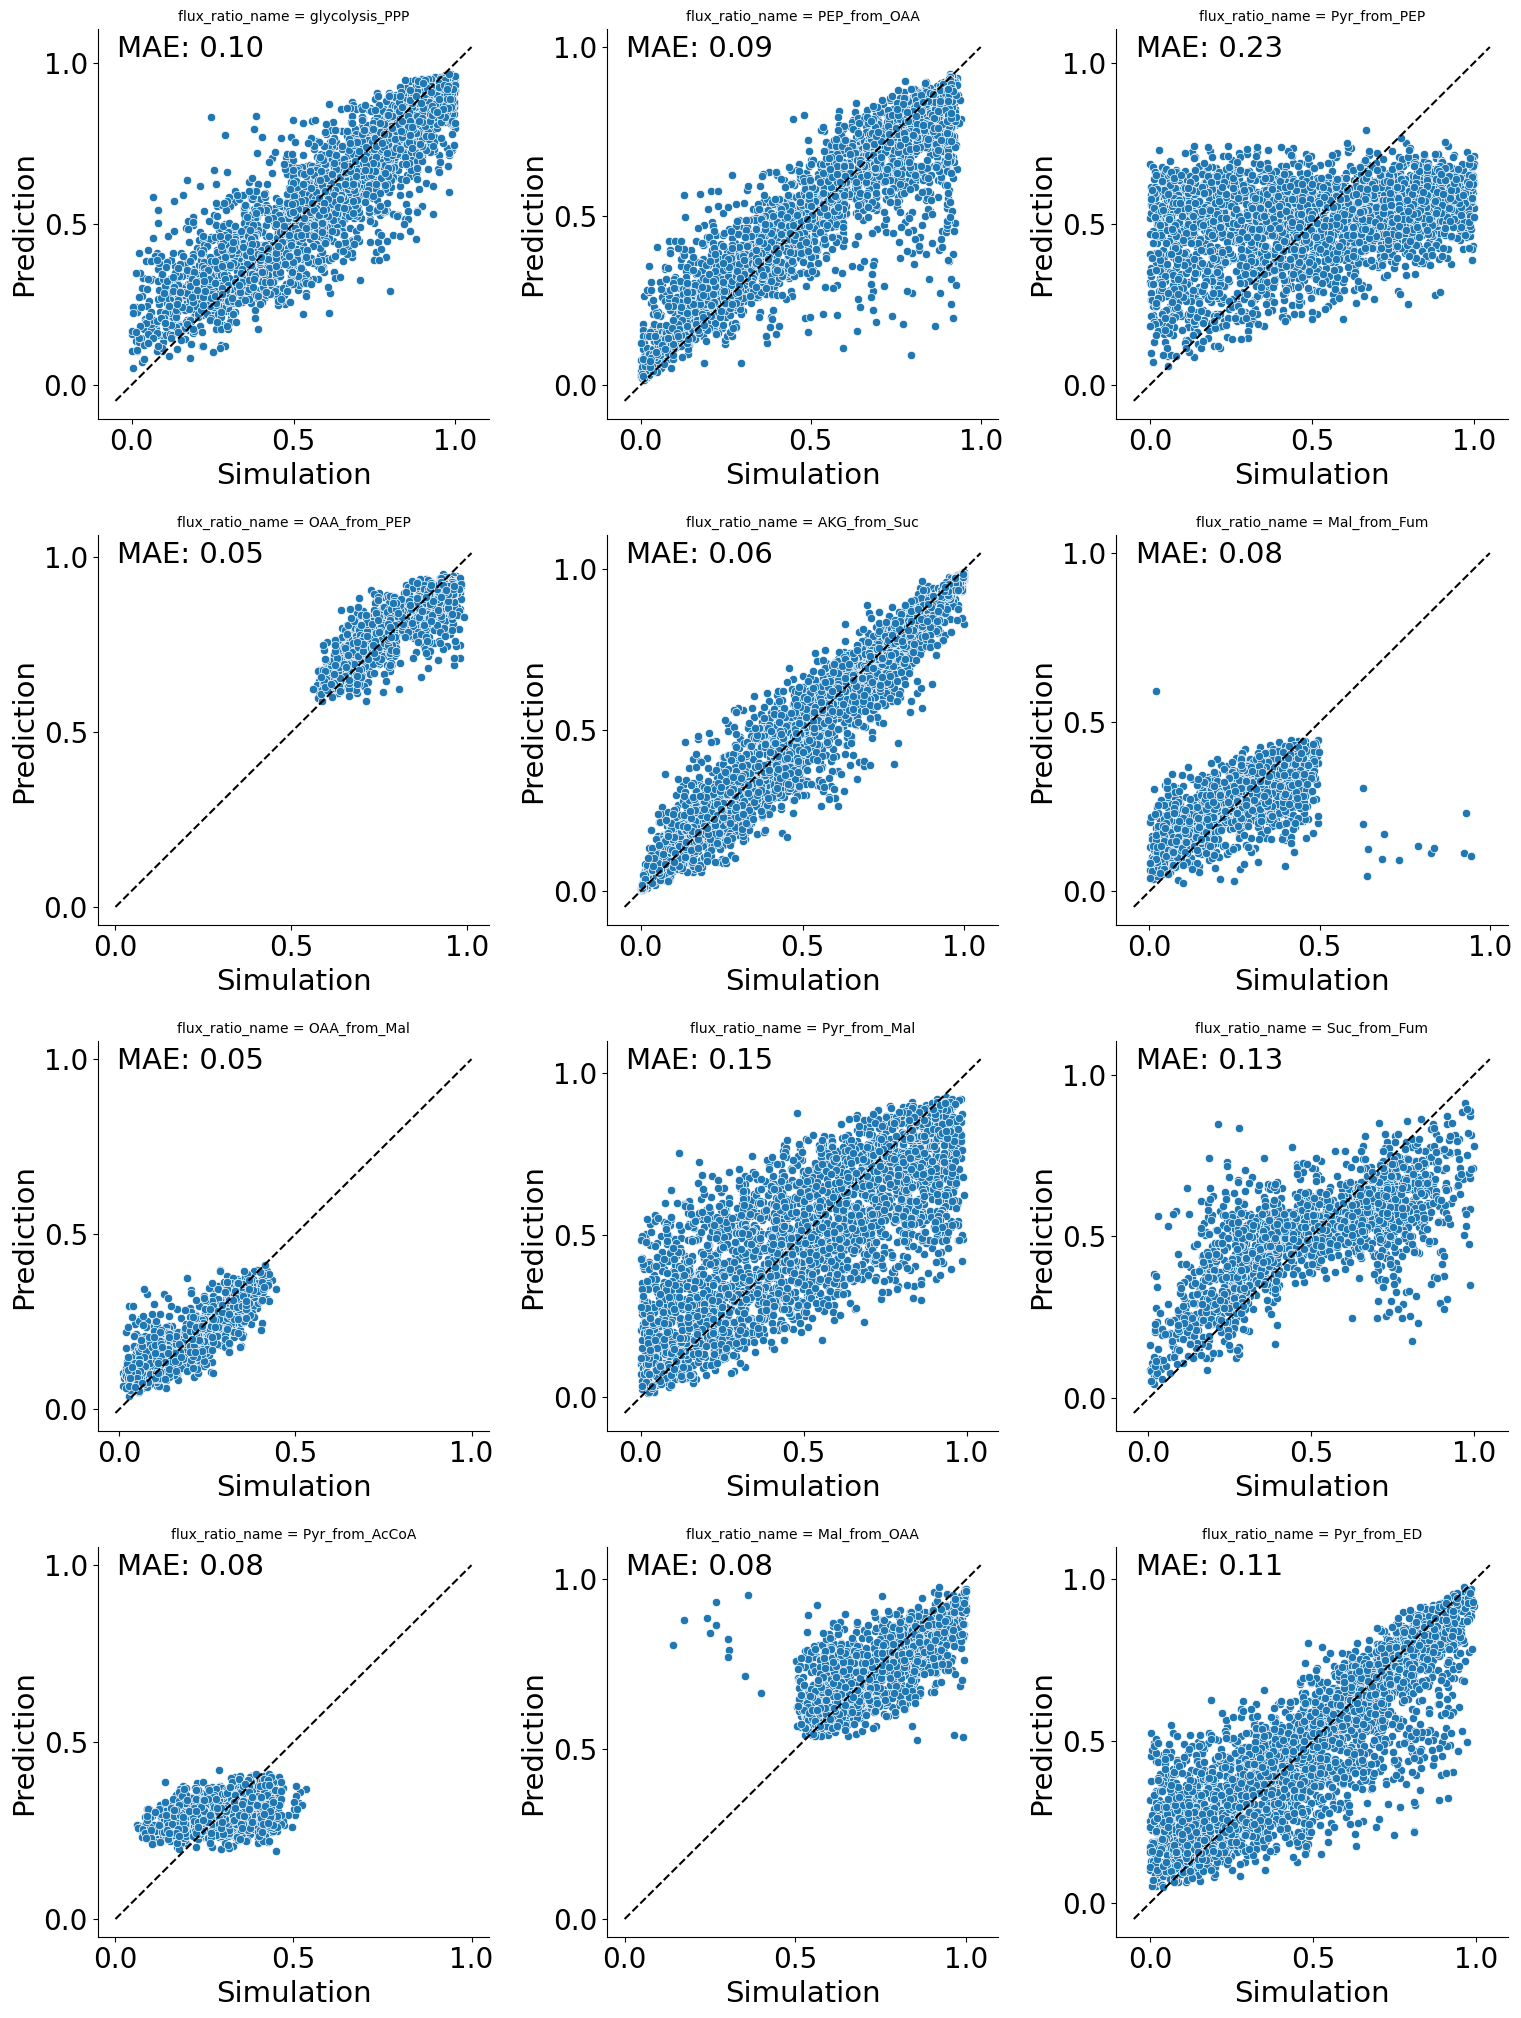

In [50]:
fg = plot_rf_results(res_dict_Ecoli_100_U13C, col_wrap=3)
fg.savefig("../Output/species_comparison_flux_ratio_prediction/Ecoli/predictors_w_noise/100_U13C.pdf", dpi = 300, bbox_inches="tight")

In [51]:

res_dict_Ecoli_100_113C = train_rf_for_all_flux_ratios(
    sim_dir = "../Output/species_comparison_flux_ratio_prediction/Ecoli/ratio_specific_simulations/", 
    flux_ratios = flux_ratios_dict_Ecoli, 
    labeling_strat = "Glc_100_113C"
)

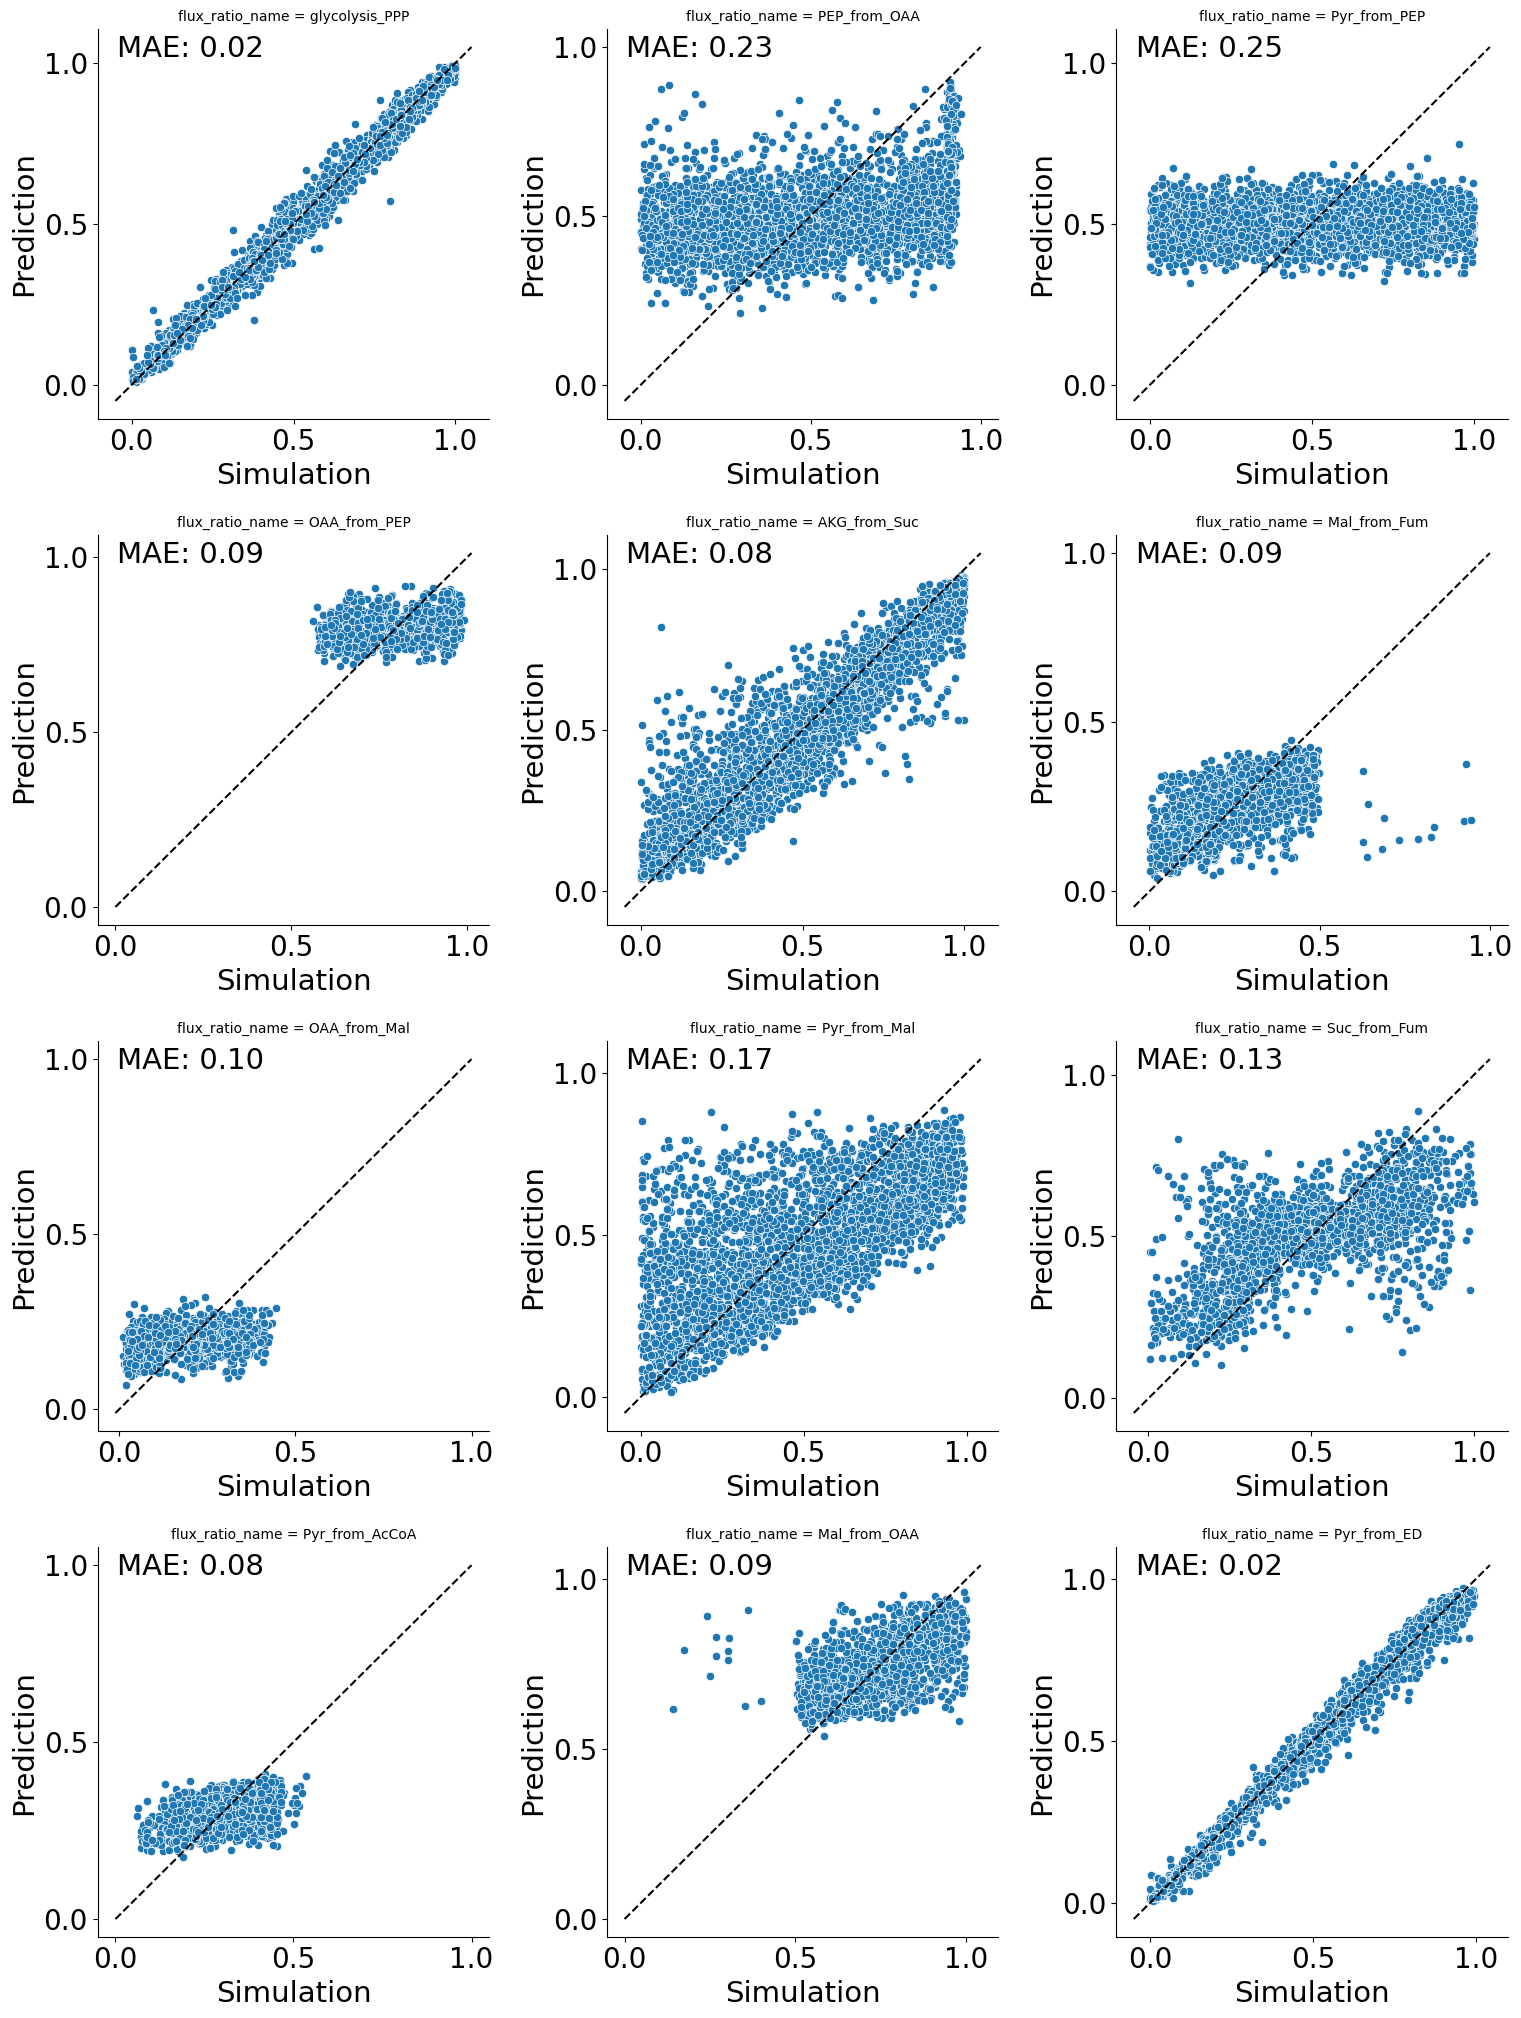

In [52]:
fg = plot_rf_results(res_dict_Ecoli_100_113C, col_wrap=3)
fg.savefig("../Output/species_comparison_flux_ratio_prediction/Ecoli/predictors_w_noise/100_113C.pdf", dpi = 300, bbox_inches="tight")

In [53]:
res_dict_Ecoli_50_U13C_50_113C = train_rf_for_all_flux_ratios(
    sim_dir = "../Output/species_comparison_flux_ratio_prediction/Ecoli/ratio_specific_simulations/", 
    flux_ratios = flux_ratios_dict_Ecoli, 
    labeling_strat = "Glc_50_U13C_50_113C"
)


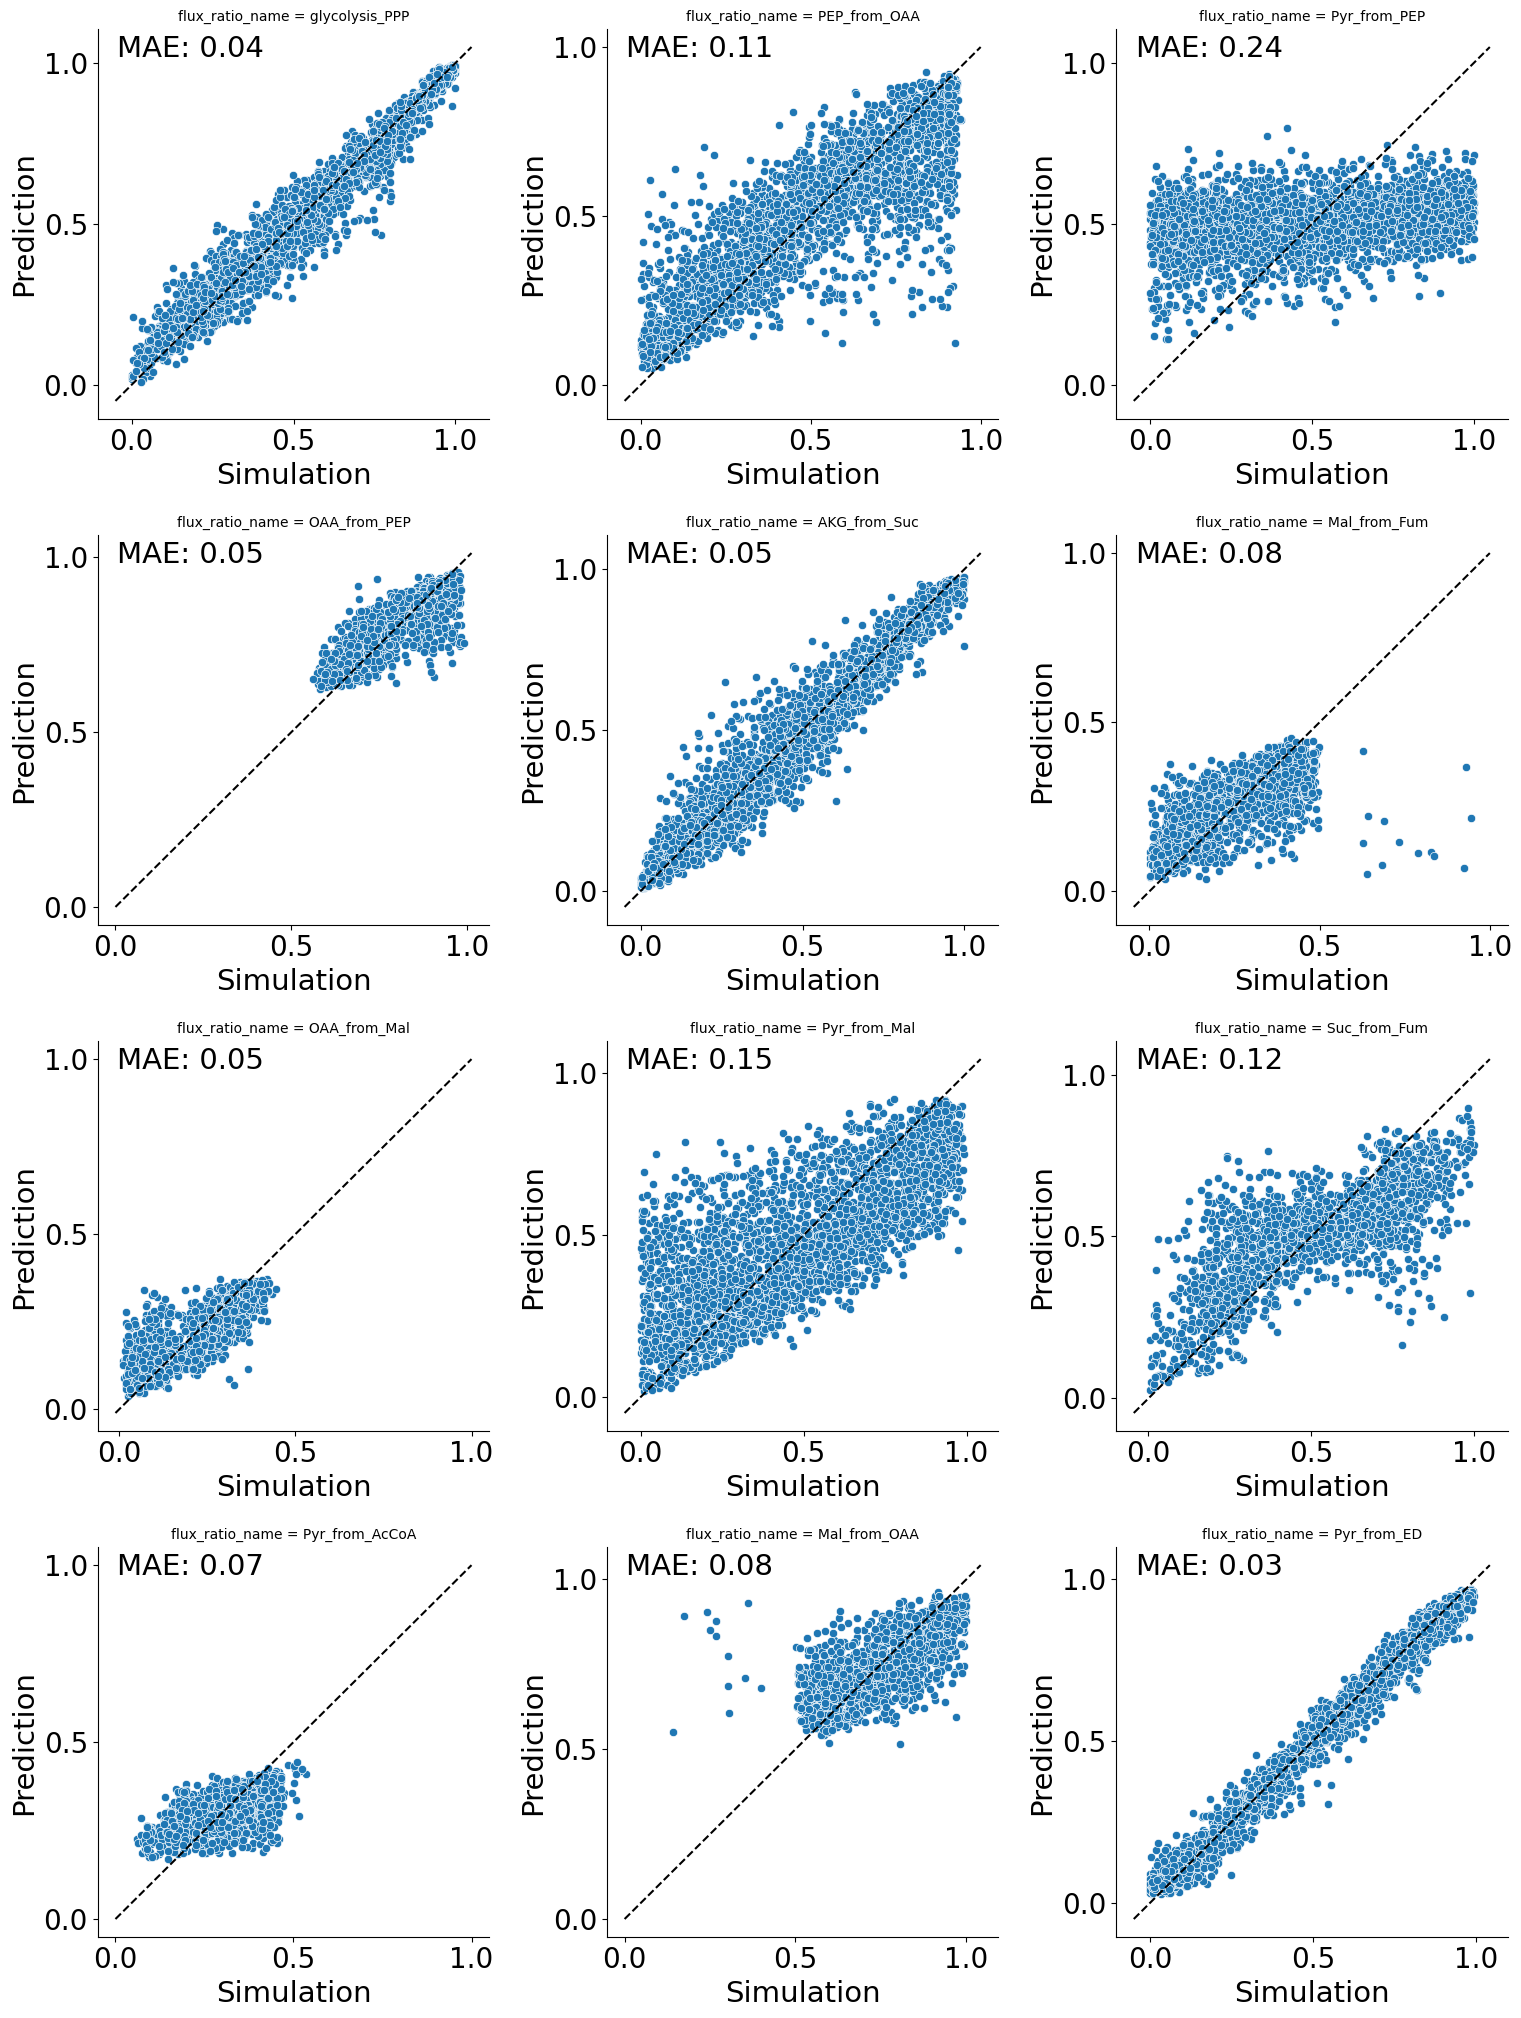

In [54]:
fg = plot_rf_results(res_dict_Ecoli_50_U13C_50_113C, col_wrap=3)
fg.savefig("../Output/species_comparison_flux_ratio_prediction/Ecoli/predictors_w_noise/50_U13C_50_113C.pdf", dpi = 300, bbox_inches="tight")

In [56]:
exp_data_100_U13C = pd.read_csv("../Data/species_comparison_flux_ratio_prediction/labeling_patterns_Glc_100_U13C.csv")
exp_data_100_113C = pd.read_csv("../Data/species_comparison_flux_ratio_prediction/labeling_patterns_Glc_100_113C.csv")
exp_data_50_U13C_50_113C = pd.read_csv("../Data/species_comparison_flux_ratio_prediction/labeling_patterns_Glc_50_U13C_50_113C.csv")


preds_Ecoli = pd.concat([
    pd.concat([
        get_rf_pred_results(
                res_dict_Ecoli_100_U13C,
                format_spec_comp_output(exp_data_100_U13C).query("strain == @species"),
                "Glc_100_U13C"
            ).assign(strain = species)
            for species in exp_data_100_U13C.strain.unique().tolist()
    ]), 
    pd.concat([
        get_rf_pred_results(
                res_dict_Ecoli_100_113C,
                format_spec_comp_output(exp_data_100_113C).query("strain == @species"),
                "Glc_100_113C"
            ).assign(strain = species)
            for species in exp_data_100_113C.strain.unique().tolist()
    ]), 
    pd.concat([
        get_rf_pred_results(
                res_dict_Ecoli_50_U13C_50_113C,
                format_spec_comp_output(exp_data_50_U13C_50_113C).query("strain == @species"),
                "Glc_50_U13C_50_113C"
            ).assign(strain = species)
            for species in exp_data_50_U13C_50_113C.strain.unique().tolist()
    ])
    
])

preds_Ecoli.to_csv("../Output/species_comparison_flux_ratio_prediction/Ecoli/predictions.csv")
